In [2]:
import os
import sys

# to setup import paths add project root dirs to sys.path
sys.path.append(os.path.join(os.getcwd(), "..", ".."))
from baseVR.base_functionality import init_import_paths
init_import_paths()


In [3]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
# %matplotlib qt
# %matplotlib widget

from analytics_processing import analytics
import analytics_processing.analytics_constants as C
from CustomLogger import CustomLogger as Logger

from dashsrc.plot_components.plot_wrappers.data_selection import group_filter_data

from analytics_processing.modality_loading import session_modality_from_nas
from analytics_processing.sessions_from_nas_parsing import sessionlist_fullfnames_from_args
from analytics_processing.sessions_from_nas_parsing import fullfnames2snames


In [4]:
data = {}
nas_dir = C.device_paths()[0]
output_dir = os.path.join(nas_dir, "Simon", "randomthings")
Logger().init_logger(None, None, logging_level="DEBUG")



In [5]:
animal_ids = [6]
paradigm_ids = [1100]
session_ids = None

In [6]:
session_dirs = sessionlist_fullfnames_from_args(paradigm_ids, animal_ids, session_ids)[0]
session_names = fullfnames2snames(session_dirs)

2026-03-26 17:13:28,687|DEBUG|3597888|sessions_from_nas_parsing|get_sessionlist_fullfnames
	Searching NAS for applicable sessions...
2026-03-26 17:13:28,689|DEBUG|3597888|sessions_from_nas_parsing|get_sessionlist_fullfnames
	For paradigms [1100], animals [6], found 34 sessions.
2026-03-26 17:13:28,690|DEBUG|3597888|sessions_from_nas_parsing|sessionlist_fullfnames_from_args
	Paradigm_ids: [1100], animal_ids: [6], session_ids: None, from_date: None, to_date: None
	Merging 34 sessions



SINGLE UNIT ACTIVATIONS
===================================

SINGLE UNIT ACTIVATIONS
===================================

SINGLE UNIT ACTIVATIONS
===================================

SINGLE UNIT ACTIVATIONS
===================================

In [7]:
# firing rates
fr_raw = analytics.get_analytics('FiringRate40msHz', session_names=session_names)
fr = fr_raw.drop("from_ephys_timestamp", axis=1)
fr.index = fr.index.droplevel((0,1,3, ))
fr.set_index('to_ephys_timestamp', append=True, inplace=True)
fr['global_t'] = np.arange(40_000, 40_000*len(fr)+1, 40_000)
fr.set_index('global_t', append=True, inplace=True)
fr.index = fr.index.rename(['session_id', 'session_t', 'global_t'])

# for concat projection
fr = fr.fillna(0)
fr_z = fr.apply(lambda unit_fr: ((unit_fr - unit_fr.mean()) / unit_fr.std()))
fr_z

2026-03-26 17:13:28,695|DEBUG|3597888|sessions_from_nas_parsing|sessionnames2fullfnames
	Inferring NAS paths for list of session names...
2026-03-26 17:13:28,697|DEBUG|3597888|sessions_from_nas_parsing|sessionlist_fullfnames_from_args
	Paradigm_ids: None, animal_ids: None, session_ids: None, from_date: None, to_date: None
	Merging 34 sessions

2026-03-26 17:13:28,697|DEBUG|3597888|analytics|get_analytics
	Processing FiringRate40msHz, (1100, 6, '2024-11-14_15-01') 2024-11-14_15-01_rYL006_P1100_LinearTrackStop_30min.hdf5
/mnt/slow/BMI/VirtualReality/SpatialSequenceLearning/RUN_rYL006/rYL006_P1100/2024-11-14_15-01_rYL006_P1100_LinearTrackStop_30min
2026-03-26 17:13:28,698|INFO|3597888|analytics|get_analytics
	Analytic `FiringRate40msHz` does not exist for (1100, 6, '2024-11-14_15-01'), compute first, or check for typo
2026-03-26 17:13:28,698|DEBUG|3597888|analytics|get_analytics
	Processing FiringRate40msHz, (1100, 6, '2024-11-14_16-40') 2024-11-14_16-40_rYL006_P1100_LinearTrackStop_21min

Unit0001  Unit0002  Unit0003  \
session_id       session_t  global_t                                    
2024-11-14_16-40 40000      40000       -0.172007 -0.360407 -0.089609   
                 80000      80000       -0.172007 -0.360407 -0.089609   
                 120000     120000      -0.172007 -0.360407 -0.089609   
                 160000     160000      -0.172007 -0.360407 -0.089609   
                 200000     200000      -0.172007 -0.360407 -0.089609   
...                                           ...       ...       ...   
2025-01-27_13-39 4435960000 53320480000 -0.172007 -0.360407 -0.089609   
                 4436000000 53320520000 -0.172007 -0.360407 -0.089609   
                 4436040000 53320560000 -0.172007 -0.360407 -0.089609   
                 4436080000 53320600000 -0.172007 -0.360407 -0.089609   
                 4436120000 53320640000 -0.172007 -0.360407 -0.089609   

                                         Unit0004  Unit0005  Unit0006  \
session_id       session_t  global_t                                    
2024-11-14_16-40 40000      40000       -0.114233 -0.128255 -0.102173   
                 80000      80000       -0.114233 -0.128255 -0.102173   
                 120000     120000      -0.114233 -0.128255 -0.102173   
                 160000     160000      -0.114233 -0.128255 -0.102173   
                 200000     200000      -0.114233 -0.128255 -0.102173   
...                                           ...       ...       ...   
2025-01-27_13-39 4435960000 53320480000 -0.114233 -0.128255 -0.102173   
                 4436000000 53320520000 -0.114233 -0.128255 -0.102173   
                 4436040000 53320560000 -0.114233 -0.128255 -0.102173   
                 4436080000 53320600000 -0.114233 -0.128255 -0.102173   
                 4436120000 53320640000 -0.114233 -0.128255 -0.102173   

                                         Unit0007  Unit0008  Unit0009  \
session_id       session_t  global_t                                    
2024-11-14_16-40 40000      40000       -0.377723 -0.280081  -0.07125   
                 80000      80000       -0.377723 -0.280081  -0.07125   
                 120000     120000      -0.377723 -0.280081  -0.07125   
                 160000     160000      -0.377723 -0.280081  -0.07125   
                 200000     200000      -0.377723 -0.280081  -0.07125   
...                                           ...       ...       ...   
2025-01-27_13-39 4435960000 53320480000 -0.377723 -0.280081  -0.07125   
                 4436000000 53320520000 -0.377723 -0.280081  -0.07125   
                 4436040000 53320560000 -0.377723 -0.280081  -0.07125   
                 4436080000 53320600000 -0.377723 -0.280081  -0.07125   
                 4436120000 53320640000 -0.377723 -0.280081  -0.07125   

                                         Unit0010  ...  Unit0068  Unit0069  \
session_id       session_t  global_t               ...                       
2024-11-14_16-40 40000      40000       -0.103342  ... -0.401366 -0.520222   
                 80000      80000       -0.103342  ... -0.401366 -0.520222   
                 120000     120000      -0.103342  ... -0.401366 -0.520222   
                 160000     160000      -0.103342  ... -0.401366 -0.520222   
                 200000     200000      -0.103342  ... -0.401366 -0.520222   
...                                           ...  ...       ...       ...   
2025-01-27_13-39 4435960000 53320480000 -0.103342  ...  2.003242 -0.520222   
                 4436000000 53320520000 -0.103342  ...  2.003242 -0.520222   
                 4436040000 53320560000 -0.103342  ...  2.003242  1.207104   
                 4436080000 53320600000 -0.103342  ...  2.003242 -0.520222   
                 4436120000 53320640000 -0.103342  ... -0.401366 -0.520222   

                                         Unit0070  Unit0071  Unit0072  \
session_id       session_t  global_t                                    
2024-11-14_16-40 40000      40

0


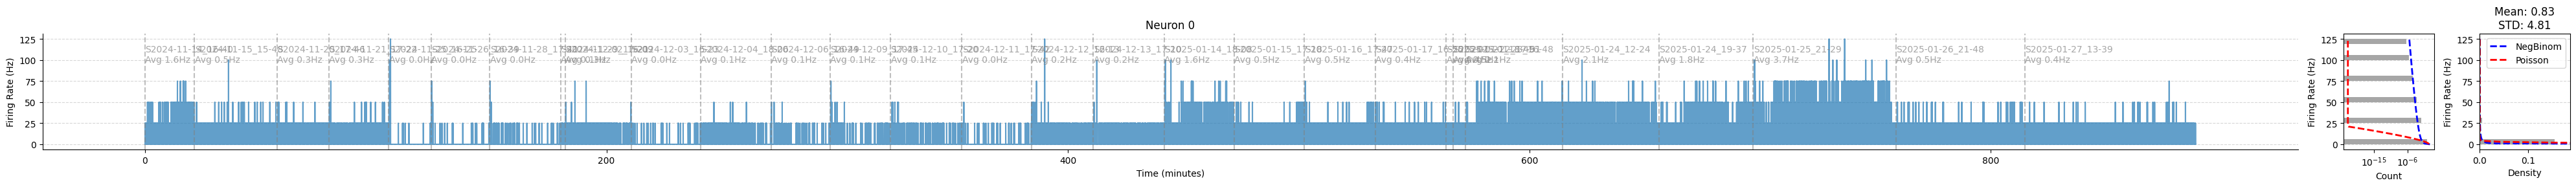

1


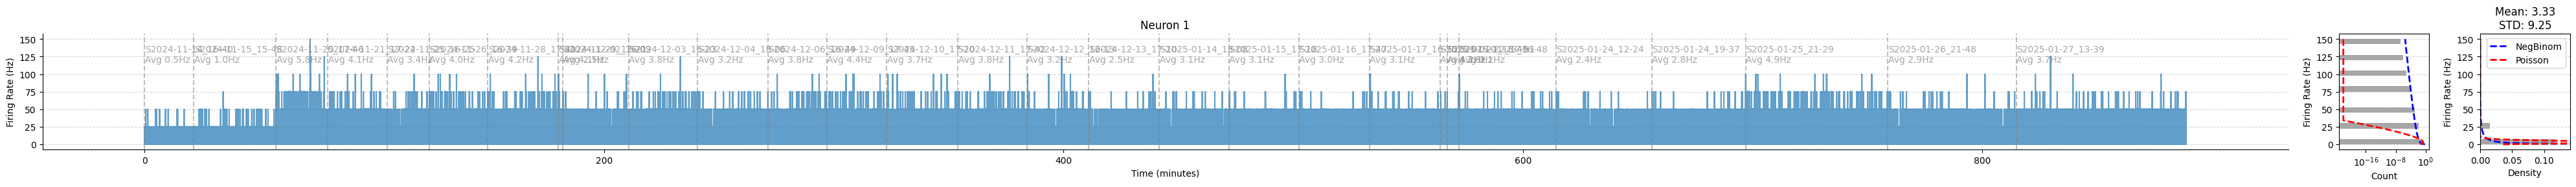

2


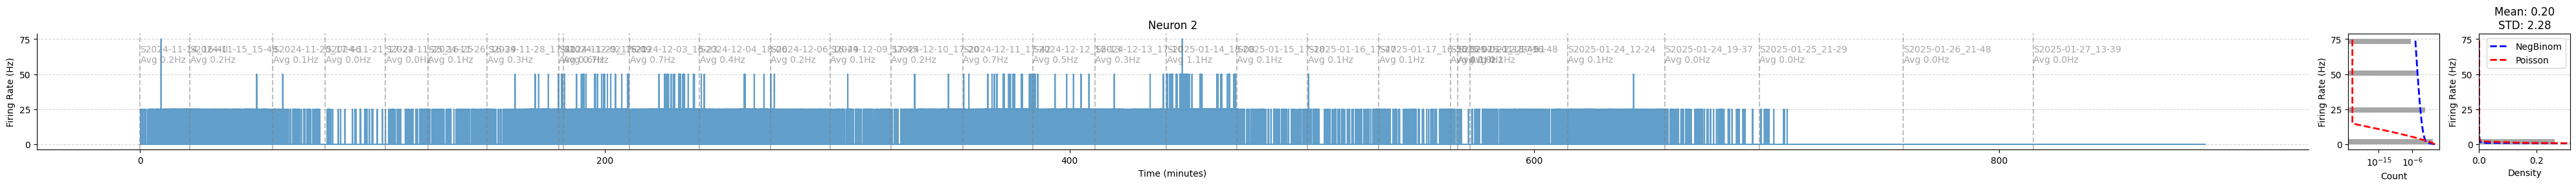

3


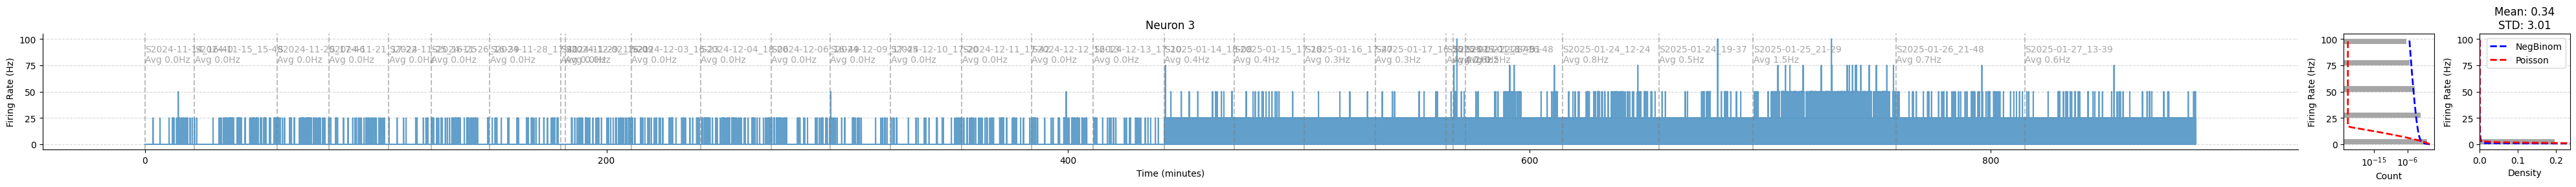

4


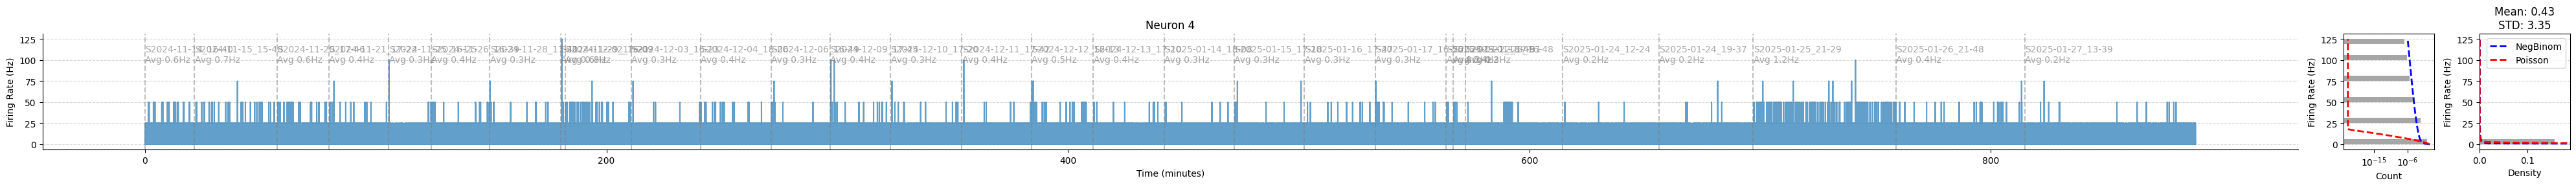

5


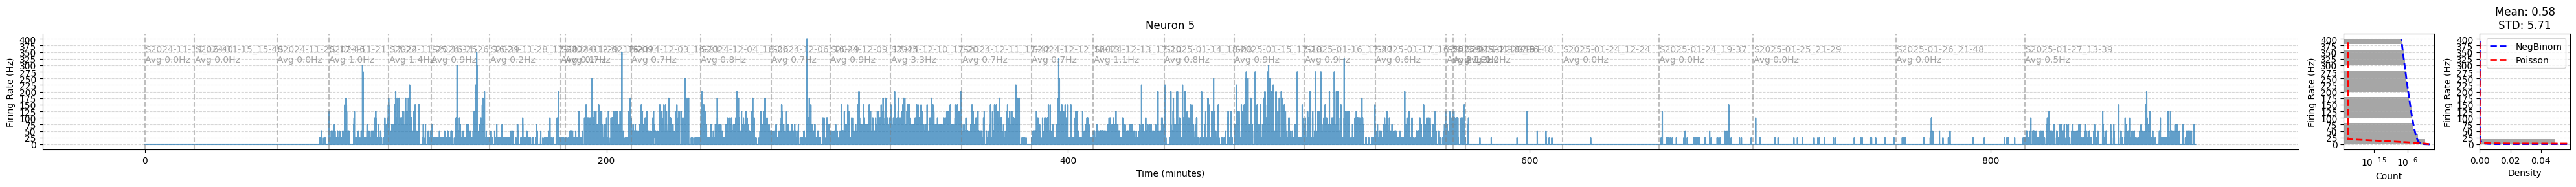

6


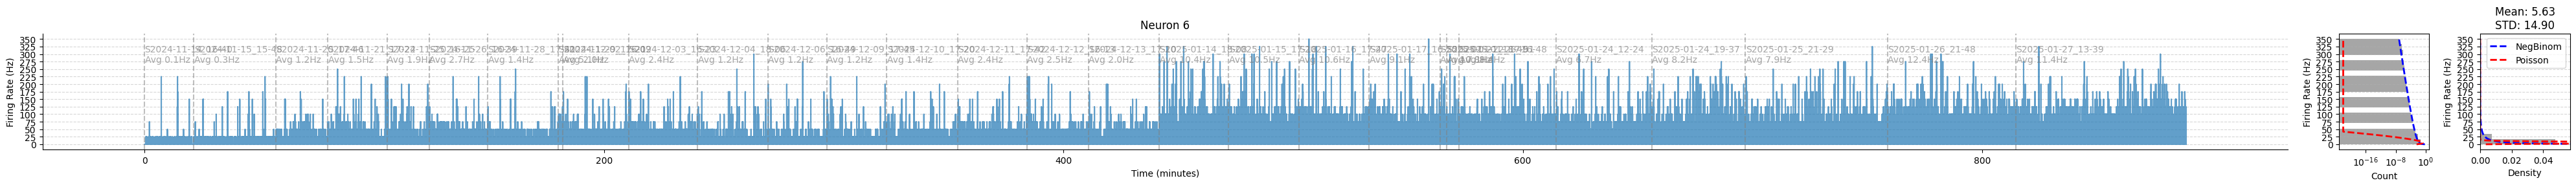

7


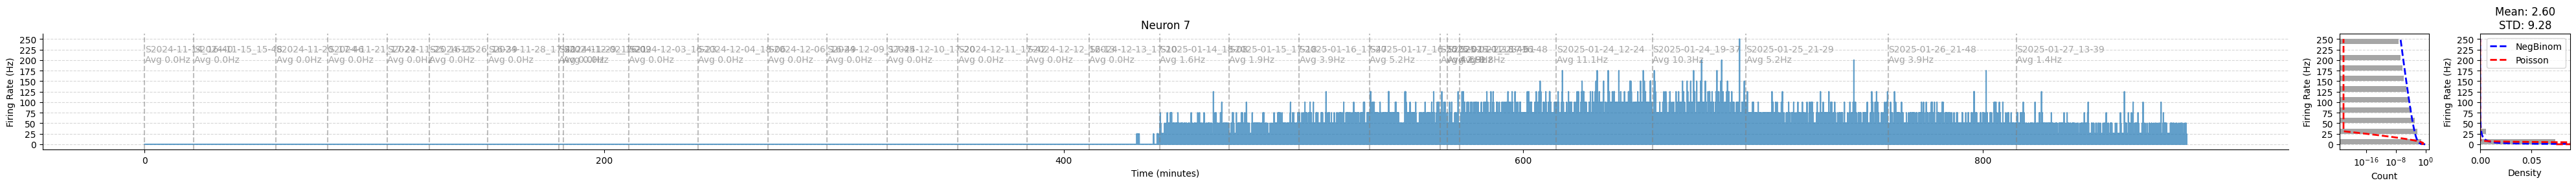

8


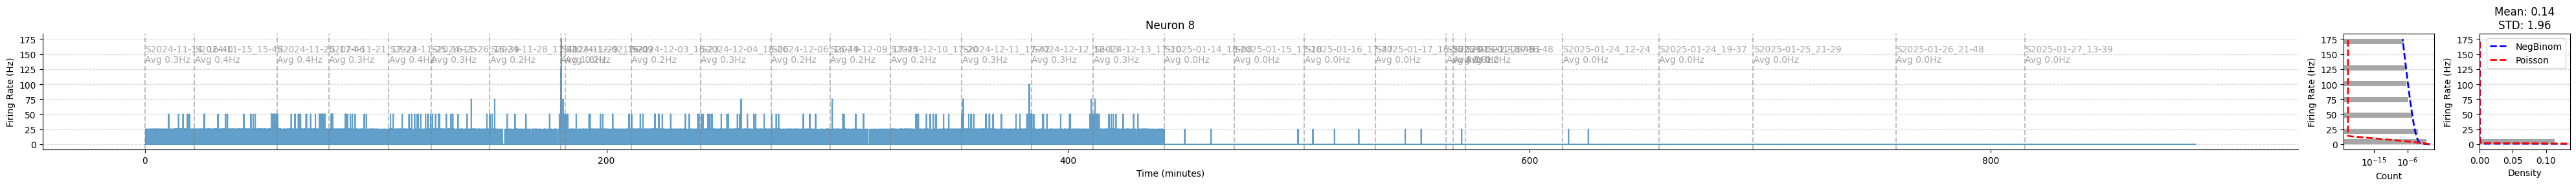

9


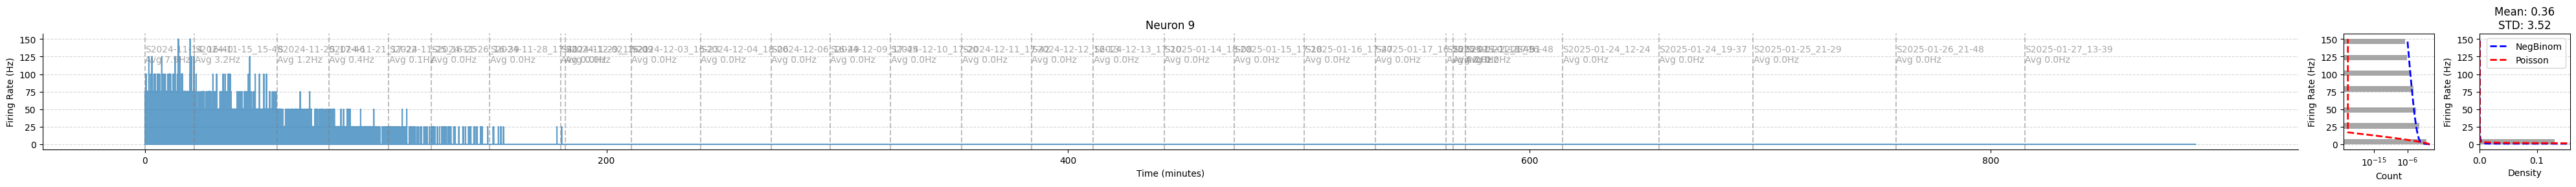

10


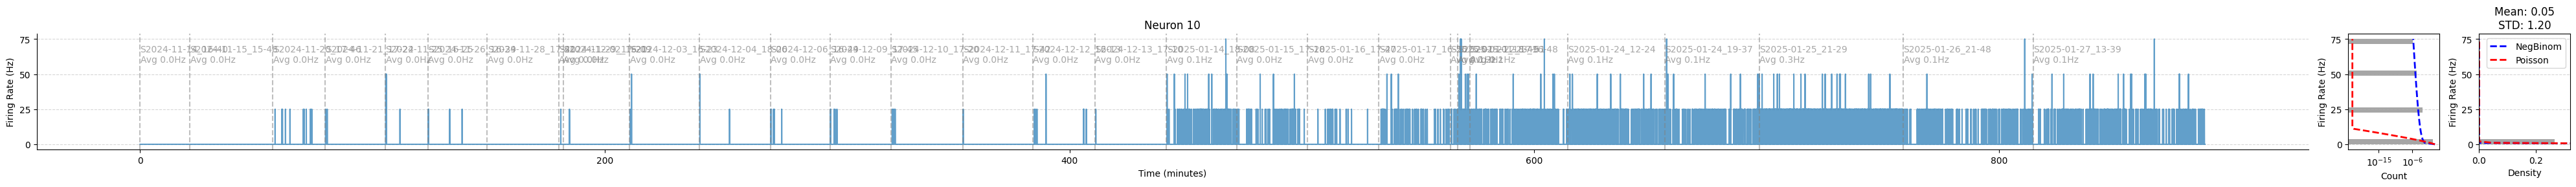

11


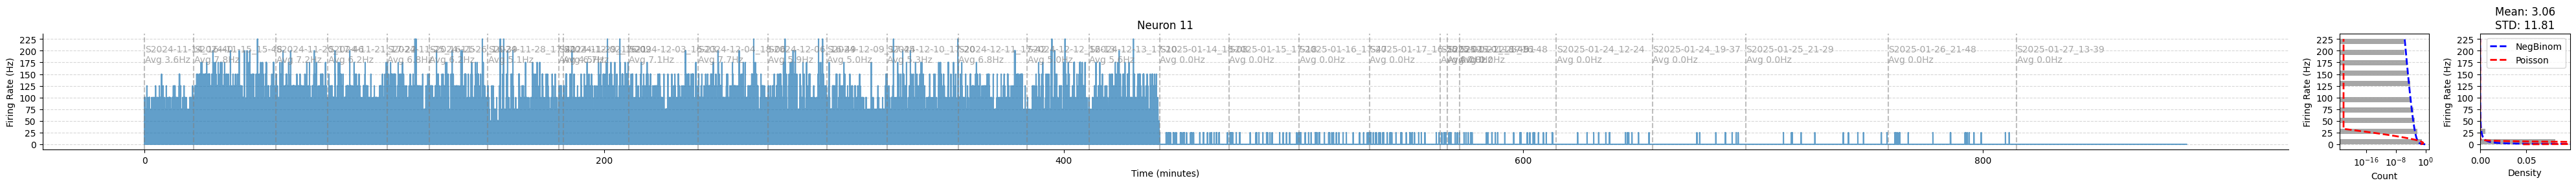

12


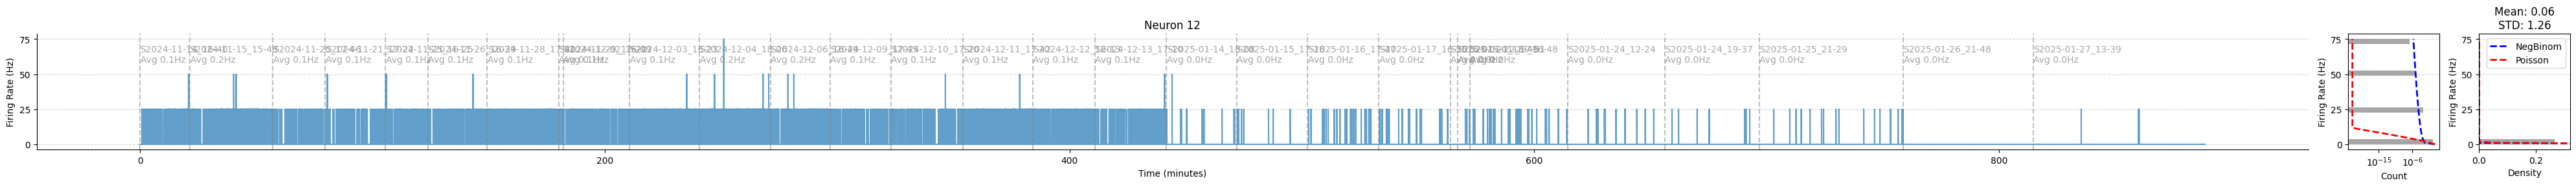

13


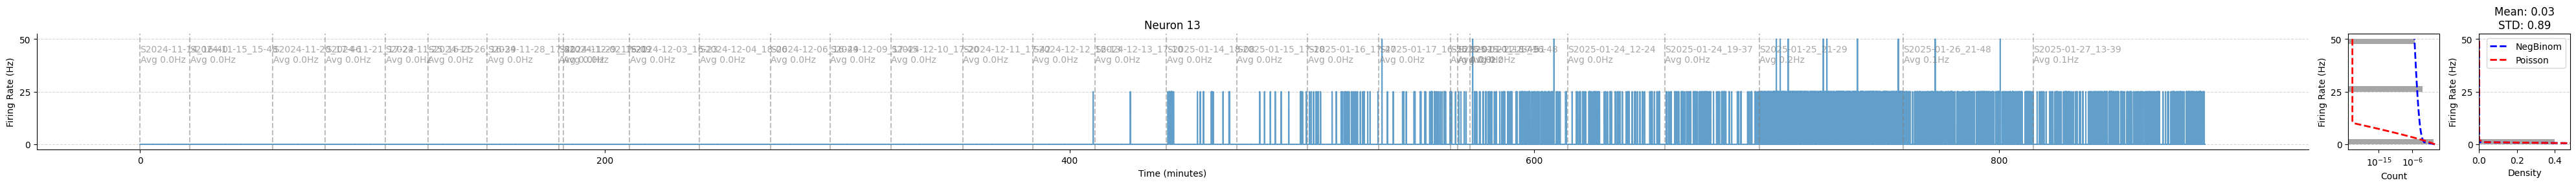

14


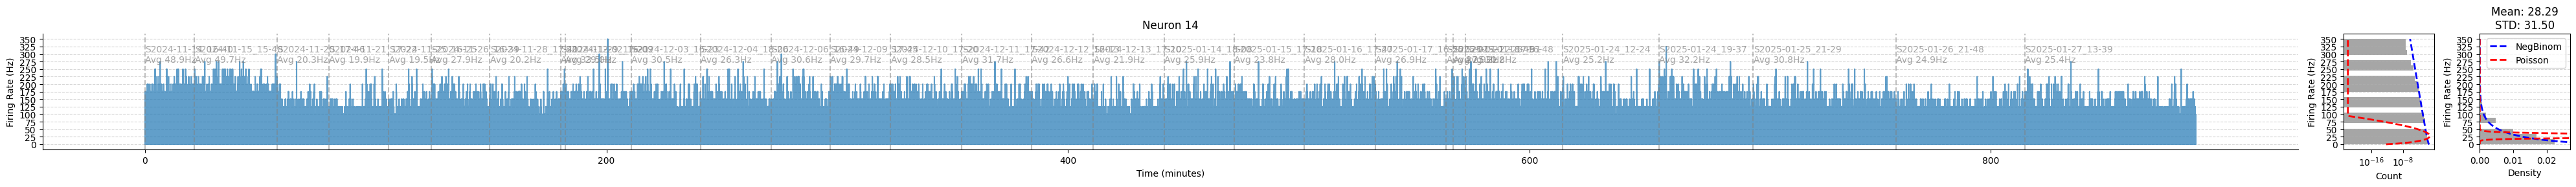

15


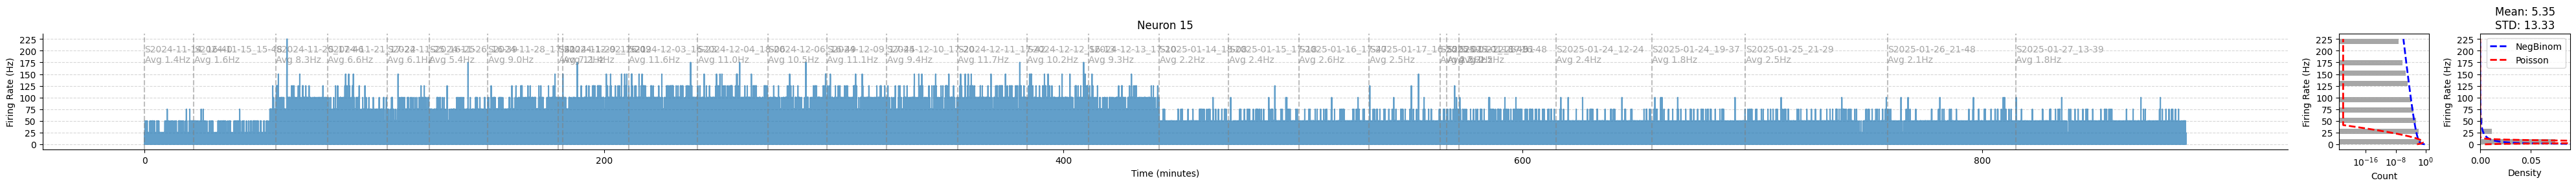

16


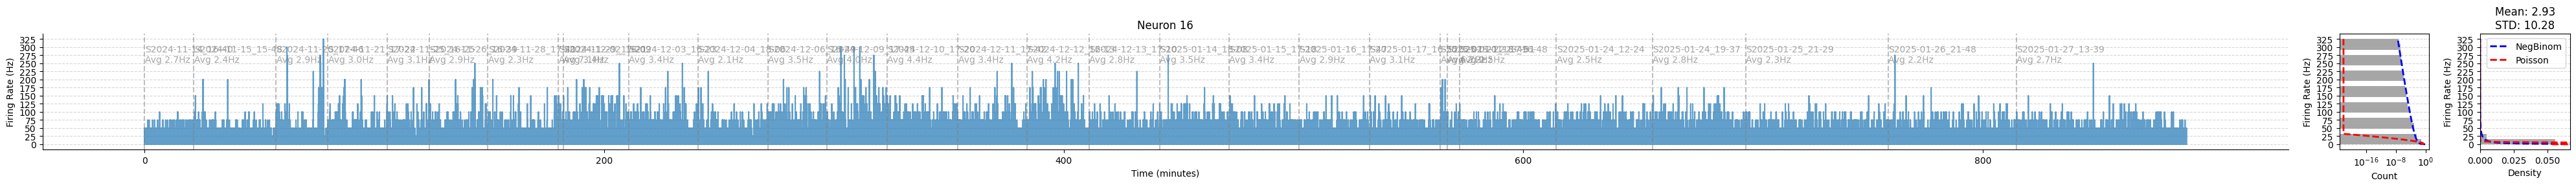

17


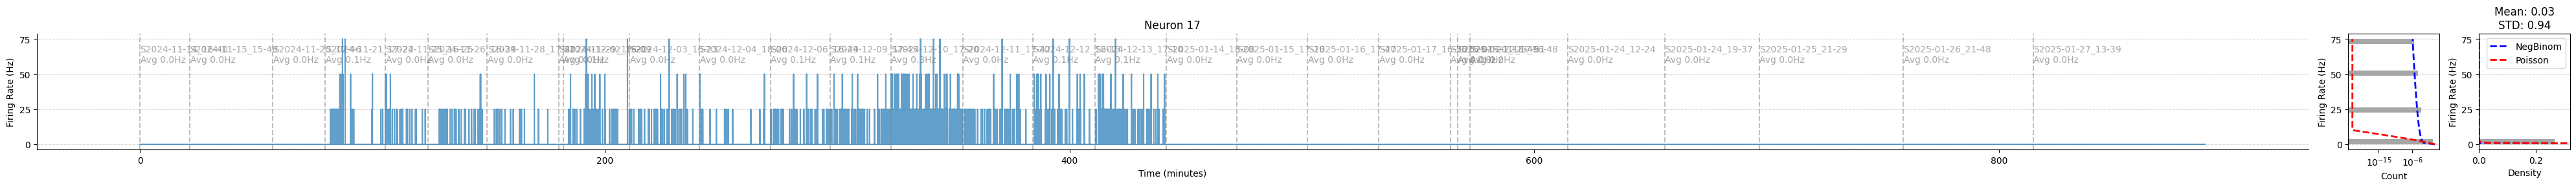

18


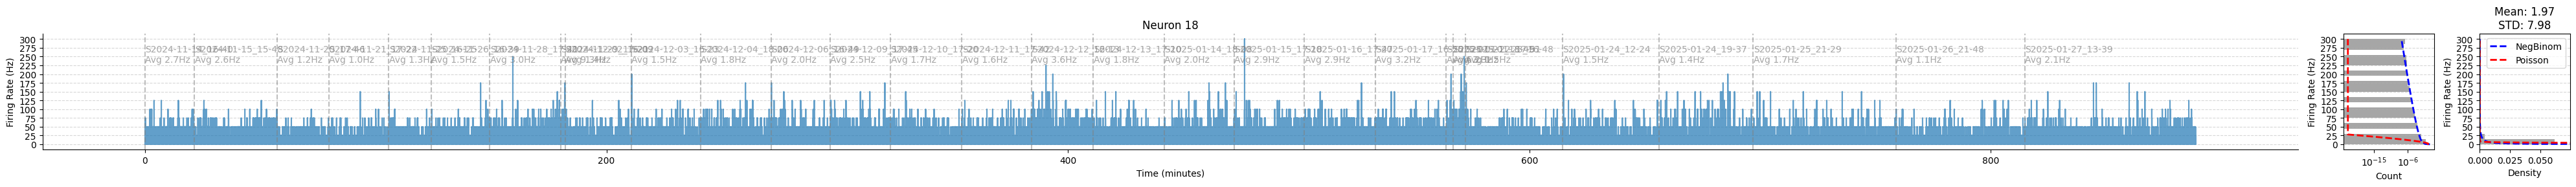

19


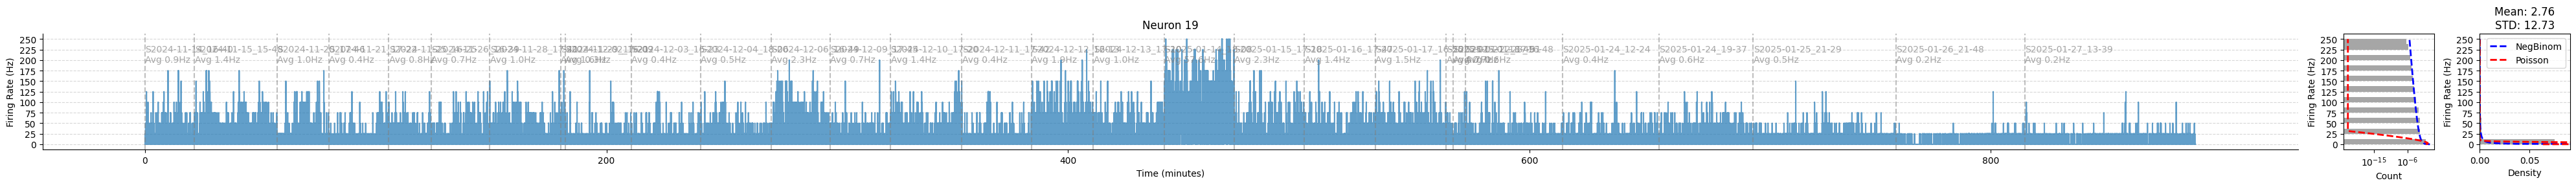

20


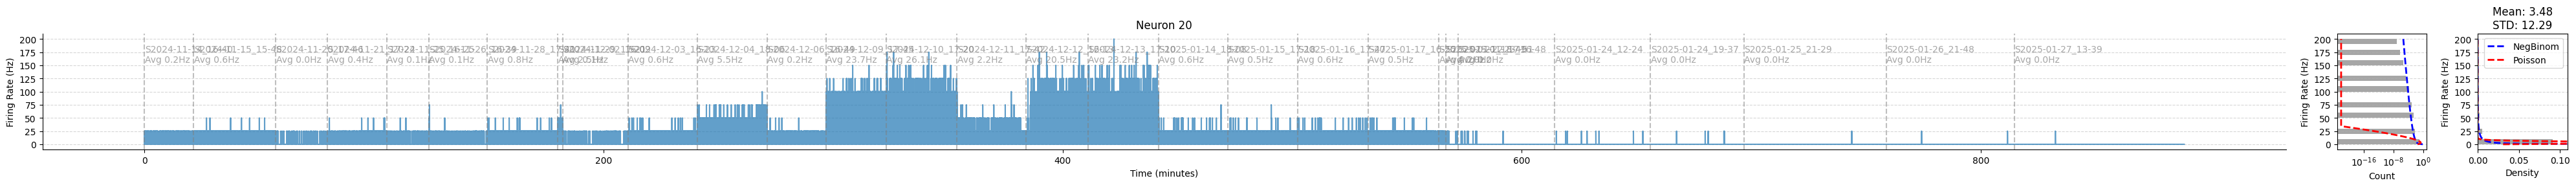

21


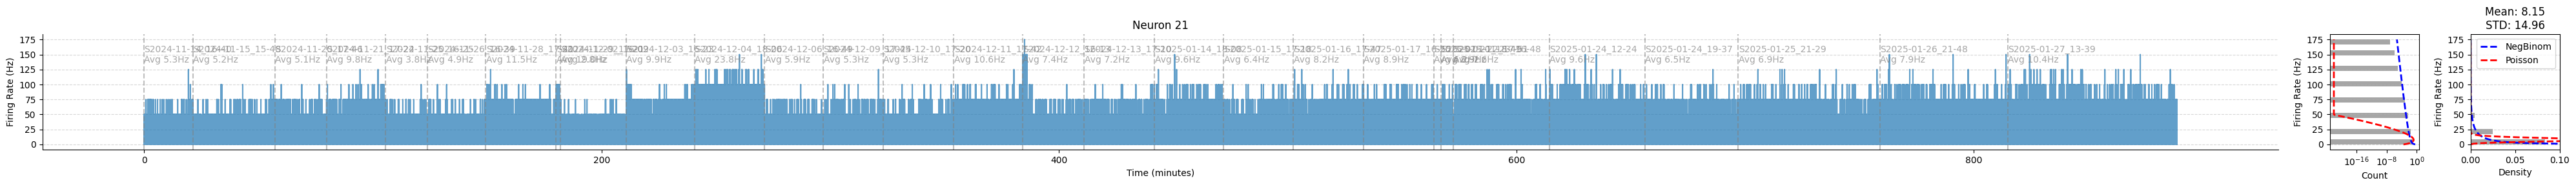

In [8]:
# ==============================================================
# === COMPUTATION UTILITIES ====================================
# ==============================================================
from scipy import stats

def compute_distribution_params(unit_hz):
    """
    Compute firing rate statistics and PMFs for Poisson and Negative Binomial.
    Returns dict with mean, std, variance, PMFs, etc.
    """
    m = unit_hz.mean()
    std = unit_hz.std()
    var = std ** 2

    # Convert firing rates to discrete counts
    discrete_counts = np.round(unit_hz.values).astype(int)
    discrete_counts = discrete_counts[discrete_counts >= 0]
    lam = discrete_counts.mean()

    # PMFs
    x = np.arange(0, max(10, discrete_counts.max()) + 1)
    pois_pmf = stats.poisson.pmf(x, lam)

    # Negative binomial params
    p = m / var if var > m else 0.999  # prevent division by zero
    r = m * p / (1 - p)
    nb_pmf = stats.nbinom.pmf(x, r, p)

    return {
        "mean": m,
        "std": std,
        "var": var,
        "lam": lam,
        "x": x,
        "pois_pmf": pois_pmf,
        "nb_pmf": nb_pmf,
    }
# import numpy as np
# import matplotlib.pyplot as plt
from matplotlib.ticker import MultipleLocator


# ==============================================================
# === PLOTTING UTILITIES =======================================
# ==============================================================

def plot_firing_rate_trace(ax, unit_hz, session_t_start, fr_index, neuron_i):
    """Plot main firing rate trace with session demarcations."""
    ax.plot(fr_index.get_level_values('global_t') / (1e6 * 60), unit_hz, alpha=0.7)
    for i in range(len(session_t_start)):
        s_id, _, global_t_start = session_t_start[i]
        global_t_end = (
            session_t_start[i + 1][2]
            if i + 1 < len(session_t_start)
            else fr_index.get_level_values('global_t').max()
        )
        avg_fr = unit_hz[
            (fr_index.get_level_values('global_t') >= global_t_start)
            & (fr_index.get_level_values('global_t') < global_t_end)
        ].mean()
        s_str = f"S{s_id:02}\nAvg {avg_fr:.1f}Hz"
        ax.axvline(global_t_start / (1e6 * 60), color='gray', linestyle='--', alpha=0.5)
        ax.text(global_t_start / (1e6 * 60) + 0.1, ax.get_ylim()[1] * 0.9, s_str,
                verticalalignment='top', color='gray', alpha=0.7)

    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.set_title(f'Neuron {neuron_i}')
    ax.set_xlabel('Time (minutes)')
    ax.set_ylabel('Firing Rate (Hz)')
    ax.yaxis.set_major_locator(MultipleLocator(25))
    ax.grid(axis='y', linestyle='--', alpha=0.5)


def plot_histograms(ax1, ax2, unit_hz, x, nb_pmf, pois_pmf):
    """Plot histogram + Poisson and NegBinom fits."""
    # First histogram (log x-scale)
    ax1.hist(unit_hz, bins=20, orientation='horizontal', color='gray', alpha=0.7, density=True)
    ax1.plot(nb_pmf, x, 'b--', lw=2)
    ax1.plot(np.clip(pois_pmf, 1e-22, None), x, 'r--', lw=2)
    ax1.set_xscale('log')
    ax1.set_xlabel('Count')
    ax1.set_ylabel('Firing Rate (Hz)')
    ax1.yaxis.set_major_locator(MultipleLocator(25))
    ax1.grid(axis='y', linestyle='--', alpha=0.5)

    # Second histogram (linear x-scale)
    bins = ax2.hist(unit_hz, bins=20, orientation='horizontal', color='gray', alpha=0.7, density=True)[0]
    ax2.plot(nb_pmf, x, 'b--', lw=2, label='NegBinom')
    ax2.plot(pois_pmf, x, 'r--', lw=2, label='Poisson')
    ax2.set_xlabel('Density')
    ax2.set_ylabel('Firing Rate (Hz)')
    ax2.legend()
    ax2.yaxis.set_major_locator(MultipleLocator(25))
    ax2.set_xlim(0, np.max(bins) * 1.2)
    ax2.grid(axis='y', linestyle='--', alpha=0.5)


# ==============================================================
# === MAIN WRAPPER =============================================
# ==============================================================

def plot_neuron_summary(fr, session_t_start, neuron_indices=None):
    """
    For each neuron, plot firing rate trace and histogram with Poisson/NB fits.
    """
    plt.close('all')
    if neuron_indices is None:
        neuron_indices = range(fr.shape[1])

    all_params = []
    for neuron_i in neuron_indices:
        print(neuron_i)
        fig, ax = plt.subplots(
            ncols=3, nrows=1, figsize=(40, 3), sharey=False,
            tight_layout=True, width_ratios=(25, 1, 1)
        )
        fig.subplots_adjust(left=0.05, right=0.95)

        unit_hz = fr.iloc[:, neuron_i]
        params = compute_distribution_params(unit_hz)
        all_params.append(params)

        plot_firing_rate_trace(ax[0], unit_hz, session_t_start, fr.index, neuron_i)
        plot_histograms(ax[1], ax[2], unit_hz, params["x"], params["nb_pmf"], params["pois_pmf"])

        # Display summary text
        m, std = params["mean"], params["std"]
        ax[2].set_title(f'Mean: {m:.2f}\nSTD: {std:.2f}')

        if neuron_i > 20:
            break
        plt.show()

    return all_params

# ==============================================================
# === EXAMPLE USAGE ============================================
# ==============================================================

session_t_start = fr.index[fr.index.get_level_values('session_t') == 40_000]

# Example call (assuming `fr` and `session_t_start` are defined):
all_params = plot_neuron_summary(fr, session_t_start)
# or for a subset:
# plot_neuron_summary(fr, session_t_start, neuron_indices=range(5))


In [9]:
from matplotlib.colors import LinearSegmentedColormap, Normalize

def fr_colors(maxval=32):
    """Return (cmap, norm) for firing-rate heatmaps.

    - maxval: maximum FR value (same scale used when building stops).
    - cmap: matplotlib colormap (continuous, 256 colors).
    - norm: Normalize(vmin=0, vmax=maxval) to pass to imshow/Scatter/Colorbar.
    """
    eps = 1e-6
    stops = [
        (0, '#ffffff'),
        ((0 + eps) / maxval, "#e8e8e8"),
        (0.1 / maxval, "#e8e8e8"),
        ((0.1 + eps) / maxval, "#8C6565"),
        (1.0 / maxval, "#8C6565"),
        ((1 + eps) / maxval, "#8C6565"),
        (2.0 / maxval, "#8C6565"),
        ((2 + eps) / maxval, "#963F3F"),
        (4.0 / maxval, "#963F3F"),
        ((4 + eps) / maxval, "#A73131"),
        (8.0 / maxval, "#A73131"),
        ((8 + eps) / maxval, "#D1552C"),
        (16.0 / maxval, "#D1552C"),
        ((16 + eps) / maxval, "#D1922C"),
        (32.0 / maxval, "#D1922C"),
    ]

    # defensive: ensure positions are in [0,1] and sorted
    stops = [(min(max(float(p), 0.0), 1.0), c) for p, c in stops]
    stops = sorted(stops, key=lambda t: t[0])

    # build a continuous colormap from the stop list
    cmap = LinearSegmentedColormap.from_list("fr_cmap", stops, N=256)

    # normalization maps data in [0, maxval] to [0,1] for the colormap
    norm = Normalize(vmin=0.0, vmax=float(maxval))
    return cmap, norm


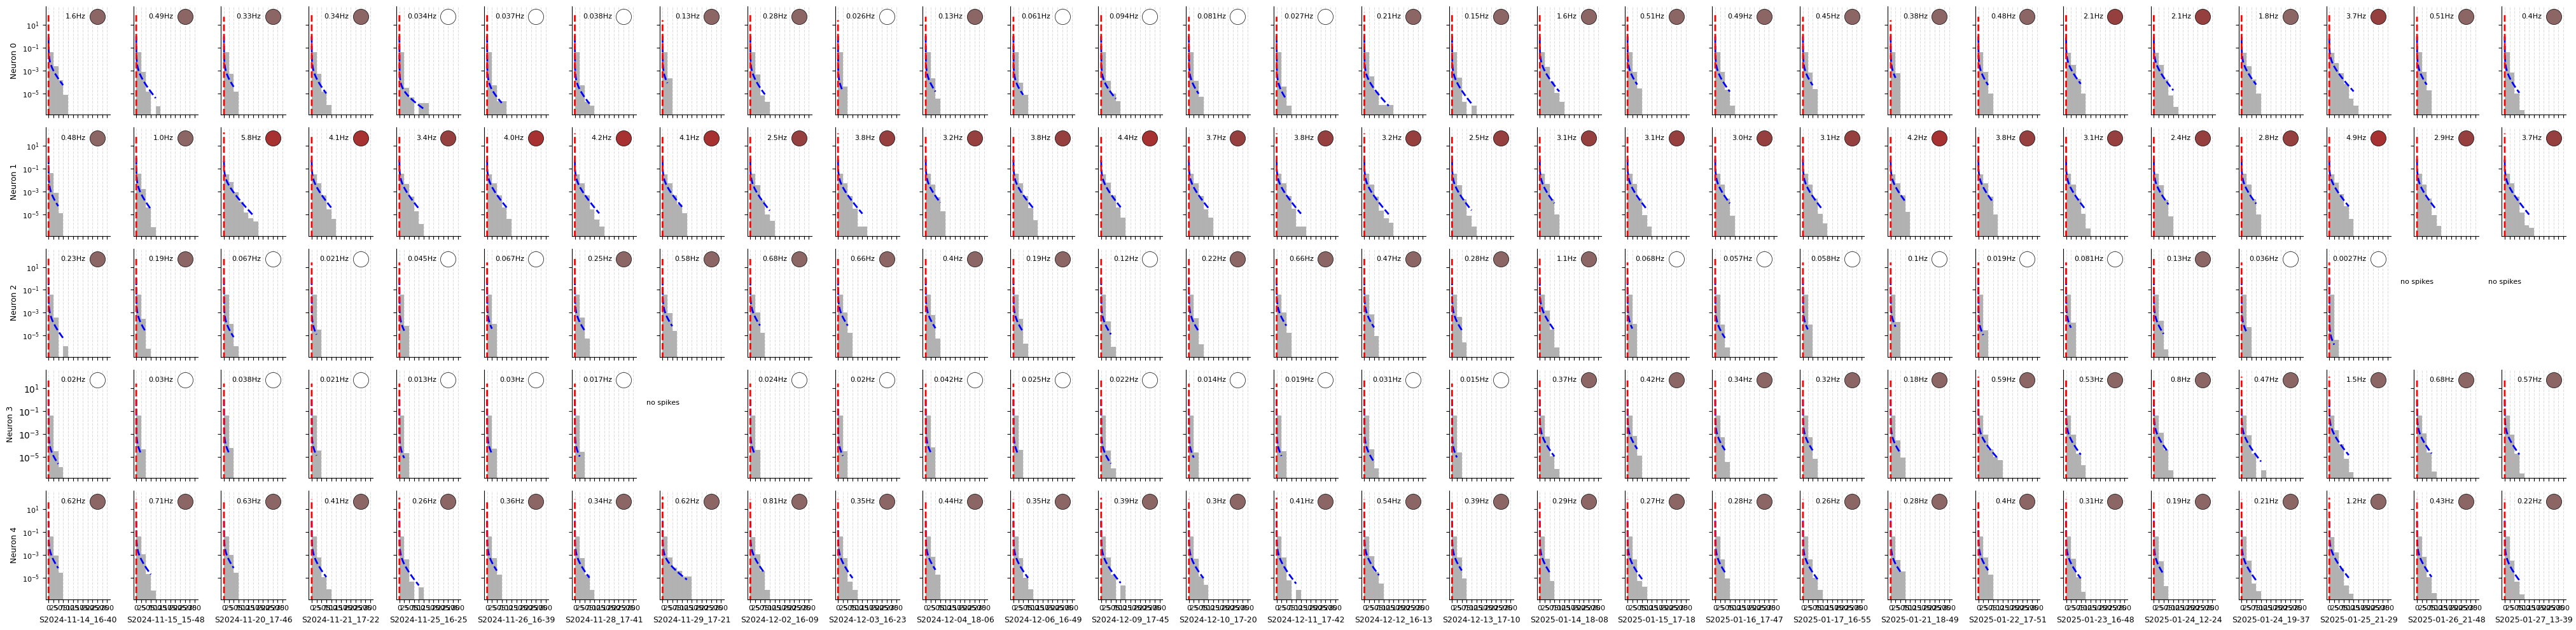

In [10]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import MultipleLocator, FormatStrFormatter
from scipy import stats

# ==============================================================
# === COMPUTATION UTILITIES ====================================
# ==============================================================
import matplotlib.colors as mcolors

def compute_distribution_params(unit_hz):
    """Compute firing rate statistics and PMFs for Poisson and Negative Binomial."""
    m = unit_hz.mean()
    std = unit_hz.std()
    var = std ** 2

    # Convert firing rates to discrete counts
    discrete_counts = np.round(unit_hz.values).astype(int)
    discrete_counts = discrete_counts[discrete_counts >= 0]
    lam = discrete_counts.mean()

    # PMFs
    x = np.arange(0, max(10, discrete_counts.max()) + 1)
    pois_pmf = stats.poisson.pmf(x, lam)

    # Negative binomial params
    p = m / var if var > m else 0.999  # prevent division by zero
    r = m * p / (1 - p)
    nb_pmf = stats.nbinom.pmf(x, r, p)

    return {
        "mean": m,
        "std": std,
        "x": x,
        "pois_pmf": pois_pmf,
        "nb_pmf": nb_pmf,
    }

# ==============================================================
# === GRID PLOTTING ============================================
# ==============================================================

def plot_neuron_session_histograms(fr, session_t_start, neuron_indices=None, n_bins=10):
    """
    Plot log(count histograms) for each neuron (rows) and session (columns).
    Each subplot shows histogram of log firing rates and mean/std in title.
    """
    if neuron_indices is None:
        neuron_indices = range(fr.shape[1])
    
    session_names = [f"S{s_id:02}" for s_id, _, _ in session_t_start]
    n_sessions = len(session_names)
    n_neurons = len(neuron_indices)

    fig, axes = plt.subplots(
        nrows=n_neurons, ncols=n_sessions,
        figsize=(1.4 * n_sessions, 2 * n_neurons),
        sharex=True, sharey=True
    )
    
    cmap, norm = fr_colors(maxval=32)
    
    # fig.colorbar(im, ax=ax, label='Firing rate (Hz)')

    # Ensure 2D array of axes
    if n_neurons == 1:
        axes = np.expand_dims(axes, 0)
    if n_sessions == 1:
        axes = np.expand_dims(axes, 1)

    fr_index = fr.index.get_level_values('global_t')

    # Compute start-end time of each session
    session_boundaries = []
    for i, (s_id, _, global_t_start) in enumerate(session_t_start):
        global_t_end = (
            session_t_start[i + 1][2]
            if i + 1 < len(session_t_start)
            else fr_index.max()
        )
        session_boundaries.append((s_id, global_t_start, global_t_end))

    # Iterate neurons × sessions
    for row, neuron_i in enumerate(neuron_indices):
        for col, (s_id, t_start, t_end) in enumerate(session_boundaries):
            ax = axes[row, col]
            unit_hz = fr.iloc[:, neuron_i]
            session_mask = (fr_index >= t_start) & (fr_index < t_end)
            session_data = unit_hz[session_mask]

            if np.all(session_data == 0):
                ax.text(0.5, 0.5, "no spikes", ha='center', va='center', fontsize=8)
                # turn off spines
                [ax.spines[side].set_visible(False) for side in ['top', 'right', 'left', 'bottom']]
                ax.set_xticks([]); ax.set_yticks([])
                # axis off
                ax.axis('off')
                continue

            params = compute_distribution_params(session_data)

            x = params["x"]
            nb_pmf = params["nb_pmf"]
            pois_pmf = params["pois_pmf"]
            ax.plot(x, nb_pmf, 'b--', lw=2, label='NegBinom')
            ax.plot(np.clip(pois_pmf, 1e-22, None), x, 'r--', lw=2)

            bin_edges = np.arange(0, 301, 25)  # 0–300 Hz in 25 Hz steps
            ax.hist(session_data, bins=bin_edges, color='gray', alpha=0.6, density=True)

            m, std = session_data.mean(), session_data.std()
            # ax.set_title(f"{m:.2f} ± {std:.2f}", fontsize=8)

            if row == n_neurons - 1:
                ax.set_xlabel(session_names[col], fontsize=9)
            if col == 0:
                ax.set_ylabel(f"Neuron {neuron_i}", fontsize=9)
            
            # draw a dot for firing rate
            # get max min x y values
            x_corner, y_corner = 250, 50
            ax.scatter([x_corner], [y_corner], color=cmap(norm(m)), s=300, 
                       edgecolor='k', linewidth=.5, zorder=3)
            ax.text(x_corner-60, y_corner, f"{m:.2}Hz", ha='right', va='center',
                    fontsize=8)
            
            sm = plt.cm.ScalarMappable(norm=norm, cmap=cmap); sm.set_array([])
            
            # add thin vertical lines every 100, 200, 300 Hz
            # [ax.axvline(x, linestyle='-', linewidth=.5, color='k', alpha=.2) 
            #  for x in (100,200,300)]
            
            # set ticks at the 25 Hz grid and format as integer labels
            ax.xaxis.set_major_locator(MultipleLocator(25))
            ax.xaxis.set_major_formatter(FormatStrFormatter('%d'))
            plt.setp(ax.xaxis.get_ticklabels(), rotation=0, fontsize=8)
            plt.setp(ax.yaxis.get_ticklabels(), rotation=0, fontsize=8)
            ax.spines['top'].set_visible(False)
            ax.spines['right'].set_visible(False)
            ax.grid(axis='x', linestyle='--', alpha=0.4)
            ax.grid(False, axis='y')
            ax.set_yscale('log')
            
            

    plt.tight_layout()
    # fig.colorbar(sm, ax=ax, label='Firing rate (Hz)')

# Example usage (unchanged)
# set of 5 neurons 
plt.close("all")
for neuron_i in range(0,5,5):
    plot_neuron_session_histograms(fr, session_t_start, neuron_indices=range(neuron_i,neuron_i+5))
    plt.show()

PCA AND ENSEMBLES OVERVIEW
=============================

PCA AND ENSEMBLES OVERVIEW
=============================

PCA AND ENSEMBLES OVERVIEW
=============================

PCA AND ENSEMBLES OVERVIEW
=============================

In [11]:
# firing rates
fr_raw = analytics.get_analytics('FiringRate40msHz', session_names=session_names)
fr = fr_raw.drop("from_ephys_timestamp", axis=1)
fr.index = fr.index.droplevel((0,1,3, ))
fr.set_index('to_ephys_timestamp', append=True, inplace=True)
fr['global_t'] = np.arange(40_000, 40_000*len(fr)+1, 40_000)
fr.set_index('global_t', append=True, inplace=True)
fr.index = fr.index.rename(['session_id', 'session_t', 'global_t'])

# for concat projection
fr = fr.fillna(0)
fr_z = fr.apply(lambda unit_fr: ((unit_fr - unit_fr.mean()) / unit_fr.std()))
fr_z

2026-03-26 17:14:22,587|DEBUG|3597888|sessions_from_nas_parsing|sessionnames2fullfnames
	Inferring NAS paths for list of session names...
2026-03-26 17:14:22,590|DEBUG|3597888|sessions_from_nas_parsing|sessionlist_fullfnames_from_args
	Paradigm_ids: None, animal_ids: None, session_ids: None, from_date: None, to_date: None
	Merging 34 sessions

2026-03-26 17:14:22,590|DEBUG|3597888|analytics|get_analytics
	Processing FiringRate40msHz, (1100, 6, '2024-11-14_15-01') 2024-11-14_15-01_rYL006_P1100_LinearTrackStop_30min.hdf5
/mnt/slow/BMI/VirtualReality/SpatialSequenceLearning/RUN_rYL006/rYL006_P1100/2024-11-14_15-01_rYL006_P1100_LinearTrackStop_30min
2026-03-26 17:14:22,591|INFO|3597888|analytics|get_analytics
	Analytic `FiringRate40msHz` does not exist for (1100, 6, '2024-11-14_15-01'), compute first, or check for typo
2026-03-26 17:14:22,591|DEBUG|3597888|analytics|get_analytics
	Processing FiringRate40msHz, (1100, 6, '2024-11-14_16-40') 2024-11-14_16-40_rYL006_P1100_LinearTrackStop_21min

Unit0001  Unit0002  Unit0003  \
session_id       session_t  global_t                                    
2024-11-14_16-40 40000      40000       -0.172007 -0.360407 -0.089609   
                 80000      80000       -0.172007 -0.360407 -0.089609   
                 120000     120000      -0.172007 -0.360407 -0.089609   
                 160000     160000      -0.172007 -0.360407 -0.089609   
                 200000     200000      -0.172007 -0.360407 -0.089609   
...                                           ...       ...       ...   
2025-01-27_13-39 4435960000 53320480000 -0.172007 -0.360407 -0.089609   
                 4436000000 53320520000 -0.172007 -0.360407 -0.089609   
                 4436040000 53320560000 -0.172007 -0.360407 -0.089609   
                 4436080000 53320600000 -0.172007 -0.360407 -0.089609   
                 4436120000 53320640000 -0.172007 -0.360407 -0.089609   

                                         Unit0004  Unit0005  Unit0006  \
session_id       session_t  global_t                                    
2024-11-14_16-40 40000      40000       -0.114233 -0.128255 -0.102173   
                 80000      80000       -0.114233 -0.128255 -0.102173   
                 120000     120000      -0.114233 -0.128255 -0.102173   
                 160000     160000      -0.114233 -0.128255 -0.102173   
                 200000     200000      -0.114233 -0.128255 -0.102173   
...                                           ...       ...       ...   
2025-01-27_13-39 4435960000 53320480000 -0.114233 -0.128255 -0.102173   
                 4436000000 53320520000 -0.114233 -0.128255 -0.102173   
                 4436040000 53320560000 -0.114233 -0.128255 -0.102173   
                 4436080000 53320600000 -0.114233 -0.128255 -0.102173   
                 4436120000 53320640000 -0.114233 -0.128255 -0.102173   

                                         Unit0007  Unit0008  Unit0009  \
session_id       session_t  global_t                                    
2024-11-14_16-40 40000      40000       -0.377723 -0.280081  -0.07125   
                 80000      80000       -0.377723 -0.280081  -0.07125   
                 120000     120000      -0.377723 -0.280081  -0.07125   
                 160000     160000      -0.377723 -0.280081  -0.07125   
                 200000     200000      -0.377723 -0.280081  -0.07125   
...                                           ...       ...       ...   
2025-01-27_13-39 4435960000 53320480000 -0.377723 -0.280081  -0.07125   
                 4436000000 53320520000 -0.377723 -0.280081  -0.07125   
                 4436040000 53320560000 -0.377723 -0.280081  -0.07125   
                 4436080000 53320600000 -0.377723 -0.280081  -0.07125   
                 4436120000 53320640000 -0.377723 -0.280081  -0.07125   

                                         Unit0010  ...  Unit0068  Unit0069  \
session_id       session_t  global_t               ...                       
2024-11-14_16-40 40000      40000       -0.103342  ... -0.401366 -0.520222   
                 80000      80000       -0.103342  ... -0.401366 -0.520222   
                 120000     120000      -0.103342  ... -0.401366 -0.520222   
                 160000     160000      -0.103342  ... -0.401366 -0.520222   
                 200000     200000      -0.103342  ... -0.401366 -0.520222   
...                                           ...  ...       ...       ...   
2025-01-27_13-39 4435960000 53320480000 -0.103342  ...  2.003242 -0.520222   
                 4436000000 53320520000 -0.103342  ...  2.003242 -0.520222   
                 4436040000 53320560000 -0.103342  ...  2.003242  1.207104   
                 4436080000 53320600000 -0.103342  ...  2.003242 -0.520222   
                 4436120000 53320640000 -0.103342  ... -0.401366 -0.520222   

                                         Unit0070  Unit0071  Unit0072  \
session_id       session_t  global_t                                    
2024-11-14_16-40 40000      40

In [12]:
pca_loadings_sessions = analytics.get_analytics('SessionPCsProj40ms', session_names=session_names)
pca_loadings_sessions = pca_loadings_sessions.drop(['from_ephys_timestamp', 'to_ephys_timestamp'], axis=1)

pca_components = analytics.get_analytics('ConcatenatedPCs40ms', session_names=session_names)
pca_components = pca_components.drop(['eigenvalues', 'explained_variance'], axis=1)

pca_loadings_sessions

2026-03-26 17:14:25,195|DEBUG|3597888|sessions_from_nas_parsing|sessionnames2fullfnames
	Inferring NAS paths for list of session names...
2026-03-26 17:14:25,198|DEBUG|3597888|sessions_from_nas_parsing|sessionlist_fullfnames_from_args
	Paradigm_ids: None, animal_ids: None, session_ids: None, from_date: None, to_date: None
	Merging 34 sessions

2026-03-26 17:14:25,198|DEBUG|3597888|analytics|get_analytics
	Processing SessionPCsProj40ms, (1100, 6, '2024-11-14_15-01') 2024-11-14_15-01_rYL006_P1100_LinearTrackStop_30min.hdf5
/mnt/slow/BMI/VirtualReality/SpatialSequenceLearning/RUN_rYL006/rYL006_P1100/2024-11-14_15-01_rYL006_P1100_LinearTrackStop_30min
2026-03-26 17:14:25,198|INFO|3597888|analytics|get_analytics
	Analytic `SessionPCsProj40ms` does not exist for (1100, 6, '2024-11-14_15-01'), compute first, or check for typo
2026-03-26 17:14:25,199|DEBUG|3597888|analytics|get_analytics
	Processing SessionPCsProj40ms, (1100, 6, '2024-11-14_16-40') 2024-11-14_16-40_rYL006_P1100_LinearTrackStop

/mnt/slow/BMI/VirtualReality/SpatialSequenceLearning/RUN_rYL006/rYL006_P1100/2024-11-14_15-01_rYL006_P1100_LinearTrackStop_30min/../../animal_analytics/ConcatenatedPCs40ms.parquet


PC1        PC2  \
paradigm_id animal_id session_id       entry_id                          
1100        6         2024-11-14_16-40 0           0.227457  -0.183954   
                                       1           0.241075  -0.156093   
                                       2           0.208335  -0.186995   
                                       3           0.189208  -0.025264   
                                       4           0.197147  -0.146542   
...                                                     ...        ...   
                      2025-01-27_13-39 110898      1.888885   0.550253   
                                       110899     -0.005224  -0.436708   
                                       110900     -0.151833  -0.056803   
                                       110901      0.045245  -0.763864   
                                       110902    131.757538  28.346370   

                                                      PC3        PC4  \
paradigm_id animal_id session_id       entry_id                        
1100        6         2024-11-14_16-40 0         0.367164   0.329095   
                                       1         0.499587   0.258211   
                                       2         0.284905   0.371784   
                                       3         0.176913   0.095874   
                                       4         0.404089   0.160490   
...                                                   ...        ...   
                      2025-01-27_13-39 110898    0.025592  -0.211725   
                                       110899   -0.146198  -0.155170   
                                       110900   -0.144484  -0.010798   
                                       110901    0.129120  -0.148415   
                                       110902    0.185186  48.042017   

                                                        PC5         PC6  \
paradigm_id animal_id session_id       entry_id                           
1100        6         2024-11-14_16-40 0          -0.130047   -0.197223   
                                       1          -0.175550   -0.197185   
                                       2          -0.089331   -0.197620   
                                       3          -0.157700   -0.198847   
                                       4          -0.143645   -0.198073   
...                                                     ...         ...   
                      2025-01-27_13-39 110898     -1.750222   -0.470017   
                                       110899      0.335579   -0.376299   
                                       110900      0.375511   -0.645119   
                                       110901      0.460209   -0.325636   
                                       110902    125.620468 -135.283749   

                                                       PC7        PC8  \
paradigm_id animal_id session_id       entry_id                         
1100        6         2024-11-14_16-40 0          0.209443  -0.256328   
                                       1          0.111642  -0.256290   
                                       2          0.245607  -0.256726   
                                       3          0.660415  -0.257952   
                                       4          0.396384  -0.257179   
...                                                    ...        ...   
                      2025-01-27_13-39 110898     0.911974  -0.157608   
                                       110899    -0.824631   0.371740   
                                       110900     0.310344   0.079134   
                                       110901     0.353204  -0.392947   
                                       110902   -38.591348 -51.259817   

                                                      PC9      PC10  ...  \
paradigm_id animal_id session_id       entry_id                      ...   
1100        6         2024-11-14_16-40 0        -0.215183 -0.191970  ...   
  

In [13]:
# project single units on PCs (every column), fr has shape every column is one unity, every row one timepoint
pca_loadings_concat = pd.DataFrame((pca_components.values @ fr_z.T.values).T, 
                                    columns=pca_loadings_sessions.columns)

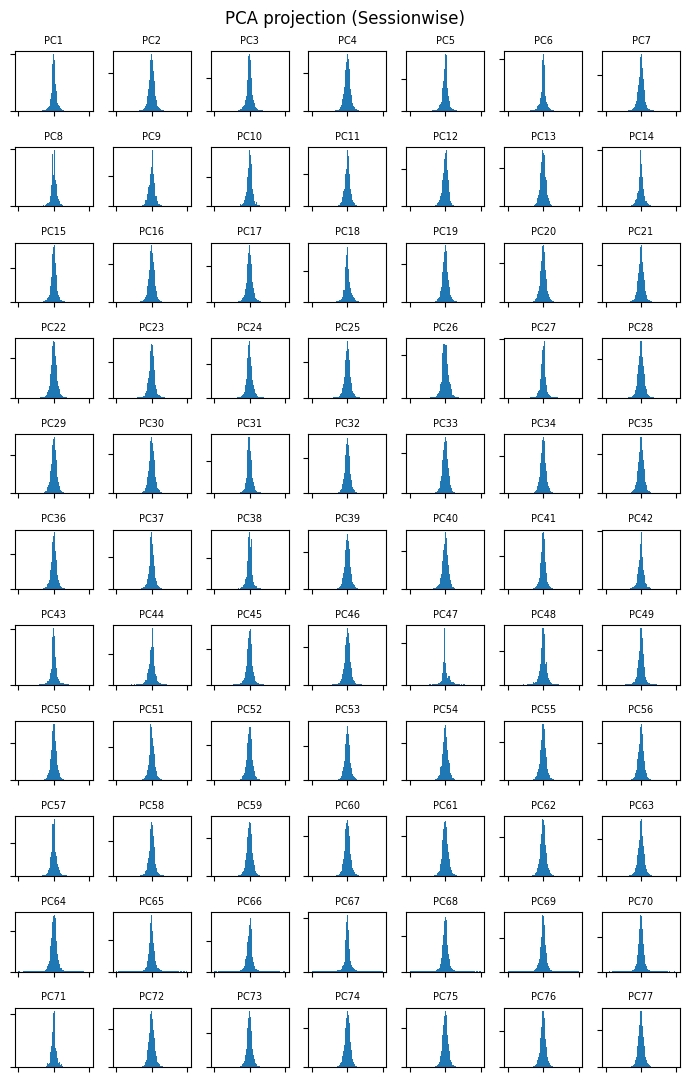

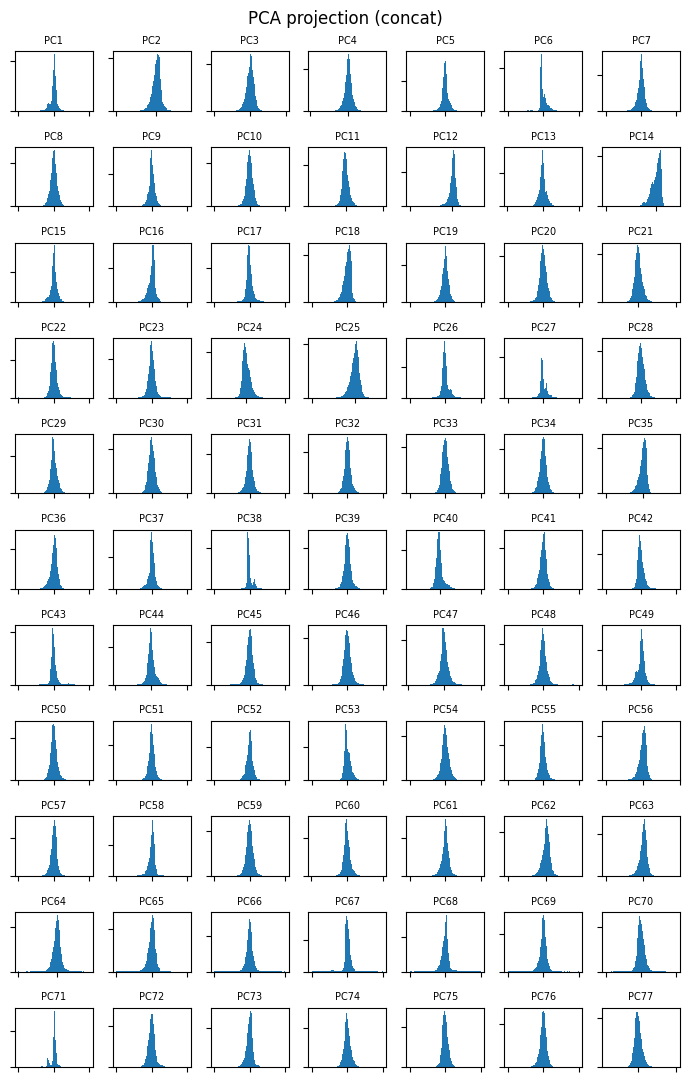

In [14]:
plt.close('all')
# Get number of columns
n_cols_data = len(pca_loadings_sessions.columns)

# Calculate grid dimensions (7 columns)
n_cols = 7
n_rows = int(np.ceil(n_cols_data / n_cols))

# Create figure with subplots
fig, axes = plt.subplots(n_rows, n_cols, figsize=(n_cols * 1, n_rows * 1), squeeze=True, )
axes = axes.flatten()

for i, col in enumerate(pca_loadings_sessions.columns):
    ax = axes[i]
    dat = pca_loadings_sessions[col]
    dat = np.clip(dat, -10, 10)
    
    ax.hist(dat.values, bins=100)
    # ax.set_yscale('log')
    ax.set_title(col, fontsize=7)
    ax.tick_params(labelleft=False, labelbottom=False)

# Hide unused subplots
for i in range(n_cols_data, len(axes)):
    axes[i].axis('off')


plt.suptitle("PCA projection (Sessionwise)")
plt.tight_layout()
plt.show()






# concatenated PCA projection is much more variable, driven by changes in firingrates over sessions

# Get number of columns
n_cols_data = len(pca_loadings_concat.columns)

# Calculate grid dimensions (7 columns)
n_cols = 7
n_rows = int(np.ceil(n_cols_data / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(n_cols * 1, n_rows * 1), squeeze=True)
# Create figure with subplots
axes = axes.flatten()

for i, col in enumerate(pca_loadings_concat.columns):
    ax = axes[i]
    dat = pca_loadings_concat[col]
    dat = np.clip(dat, -10, 10)
    
    ax.hist(dat.values, bins=100)
    # ax.set_yscale('log')
    ax.tick_params(labelleft=False, labelbottom=False)
    ax.set_title(col, fontsize=7)

# Hide unused subplots
for i in range(n_cols_data, len(axes)):
    axes[i].axis('off')

plt.suptitle("PCA projection (concat)")
plt.tight_layout()
# plt.show()

In [15]:
ensambles = analytics.get_analytics('ConcatenatedEnsambles40ms', session_names=session_names)
ensambles



2026-03-26 17:14:46,583|DEBUG|3597888|sessions_from_nas_parsing|sessionnames2fullfnames
	Inferring NAS paths for list of session names...
2026-03-26 17:14:46,585|DEBUG|3597888|sessions_from_nas_parsing|sessionlist_fullfnames_from_args
	Paradigm_ids: None, animal_ids: None, session_ids: None, from_date: None, to_date: None
	Merging 34 sessions

2026-03-26 17:14:46,586|DEBUG|3597888|analytics|get_analytics
	Processing ConcatenatedEnsambles40ms, for n=34 sessions
2026-03-26 17:14:46,602|INFO|3597888|analytics|get_analytics
	Loaded animal-level analytic `ConcatenatedEnsambles40ms` last modified on 2026-03-23T12:48:38.824145


/mnt/slow/BMI/VirtualReality/SpatialSequenceLearning/RUN_rYL006/rYL006_P1100/2024-11-14_15-01_rYL006_P1100_LinearTrackStop_30min/../../animal_analytics/ConcatenatedEnsambles40ms.parquet


,Assembly001,Assembly002,Assembly003,Assembly004,Assembly005,Assembly006,Assembly007,Assembly008,Assembly009,Assembly010,...,Assembly014,Assembly015,Assembly016,Assembly017,Assembly018,Assembly019,Assembly020,Assembly021,Assembly022,Assembly023
0,-0.007620,-0.026573,-0.010349,0.013573,-0.598716,-0.011359,0.006246,0.003455,-0.012089,0.001278,...,0.002649,0.008498,-0.012974,0.002732,0.013380,0.030109,-0.004973,0.027152,-0.001781,0.017863
1,0.045658,0.175509,0.077437,-0.004664,-0.026553,-0.003270,-0.007405,-0.052149,0.180782,0.020086,...,-0.008011,-0.010138,-0.012111,0.001653,-0.516077,0.035318,-0.048191,-0.020027,0.048238,-0.087214
2,0.010040,-0.012086,-0.005691,-0.002109,0.032244,0.006258,0.017659,0.038180,-0.028504,-0.021451,...,0.000443,0.001398,-0.007994,0.010366,-0.699748,0.001800,0.055084,-0.022802,-0.037287,-0.007965
3,0.004320,-0.000709,0.020682,0.030223,-0.173876,-0.019167,0.025496,-0.022999,0.002305,0.017461,...,-0.013267,-0.003933,-0.022325,-0.007743,-0.078004,0.005915,-0.058495,-0.009877,-0.005245,-0.135142
4,0.012085,0.011409,-0.031820,0.023285,-0.634643,0.014083,-0.026461,0.028788,0.024019,0.012473,...,-0.001875,-0.001851,-0.000643,0.006167,0.037504,-0.049953,-0.023400,-0.002684,0.020493,0.078588
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
72,-0.008495,0.008644,-0.003513,0.004848,-0.016281,0.635420,-0.008987,-0.019280,-0.000862,0.030654,...,0.016379,0.013851,0.009954,0.000234,-0.003852,-0.010269,0.027721,0.053196,-0.013451,0.035508
73,-0.060573,0.015221,0.052229,-0.048880,0.002319,0.004589,-0.004035,-0.223293,0.004947,-0.027151,...,-0.015887,-0.014372,0.000399,-0.014106,0.005821,-0.124696,0.053304,0.029672,-0.004352,-0.158488
74,0.032165,0.084581,0.122795,0.065813,0.010363,0.027311,-0.060536,0.095280,0.085327,-0.010383,...,-0.039116,0.008661,0.007375,0.034909,0.089483,0.201991,-0.008872,-0.119077,-0.014311,-0.044518
75,-0.033695,0.063231,0.110898,0.059889,0.040149,0.109573,0.006530,0.044539,0.475507,-0.027311,...,-0.005511,-0.010718,-0.008305,0.038061,0.042285,0.063200,-0.047800,-0.054104,0.096990,-0.103244


In [16]:
ensambles.shape

(77, 23)

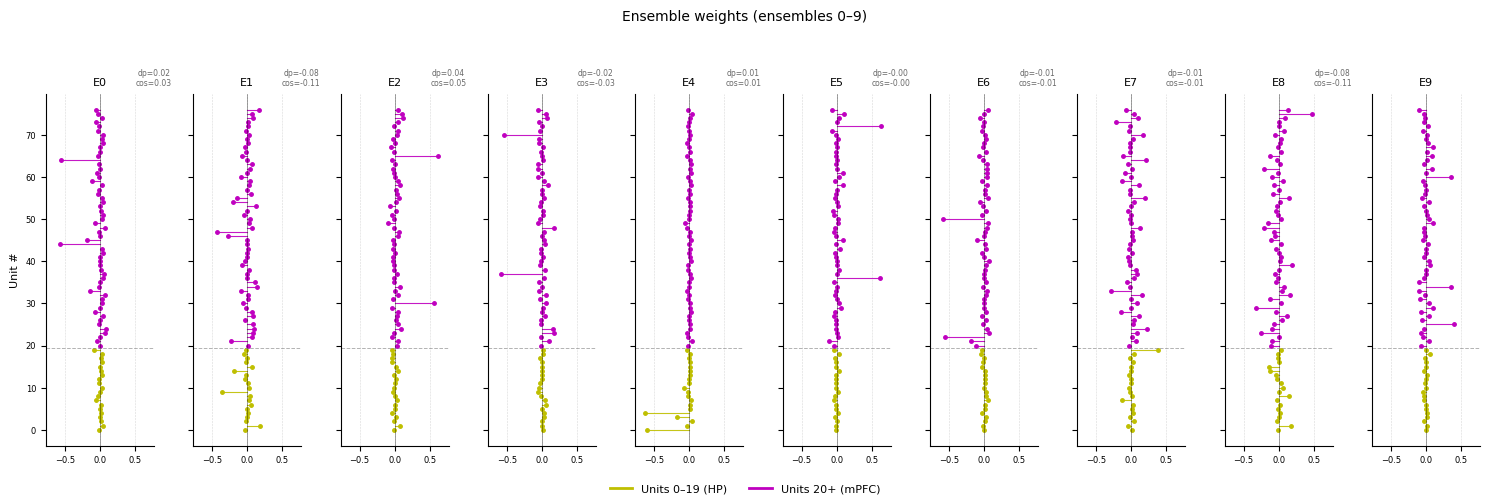

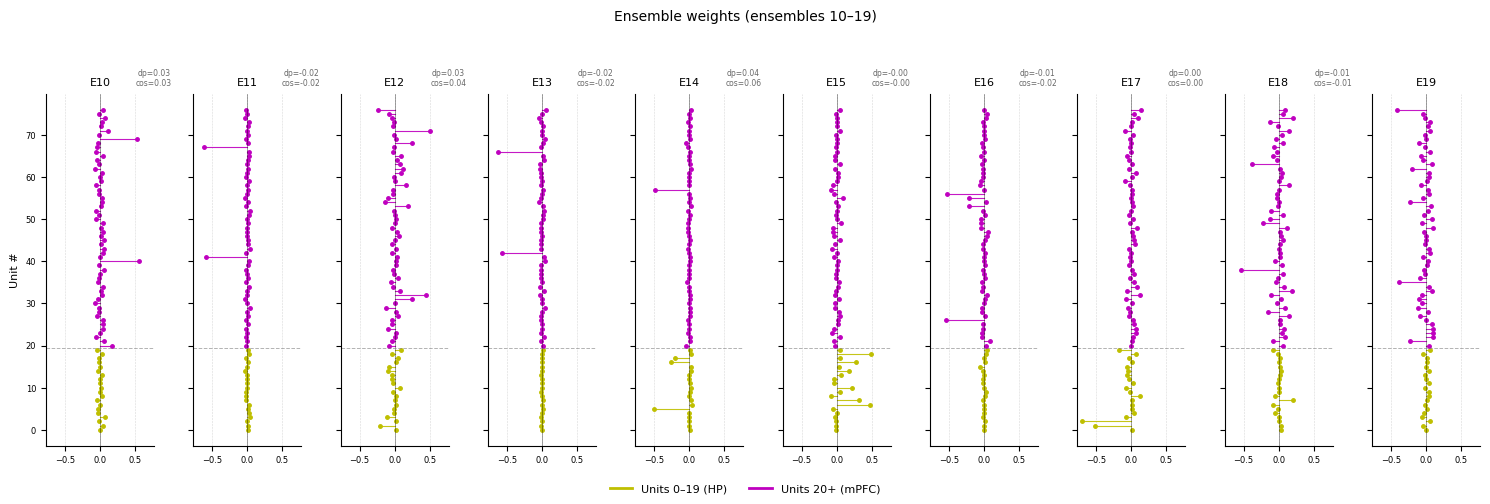

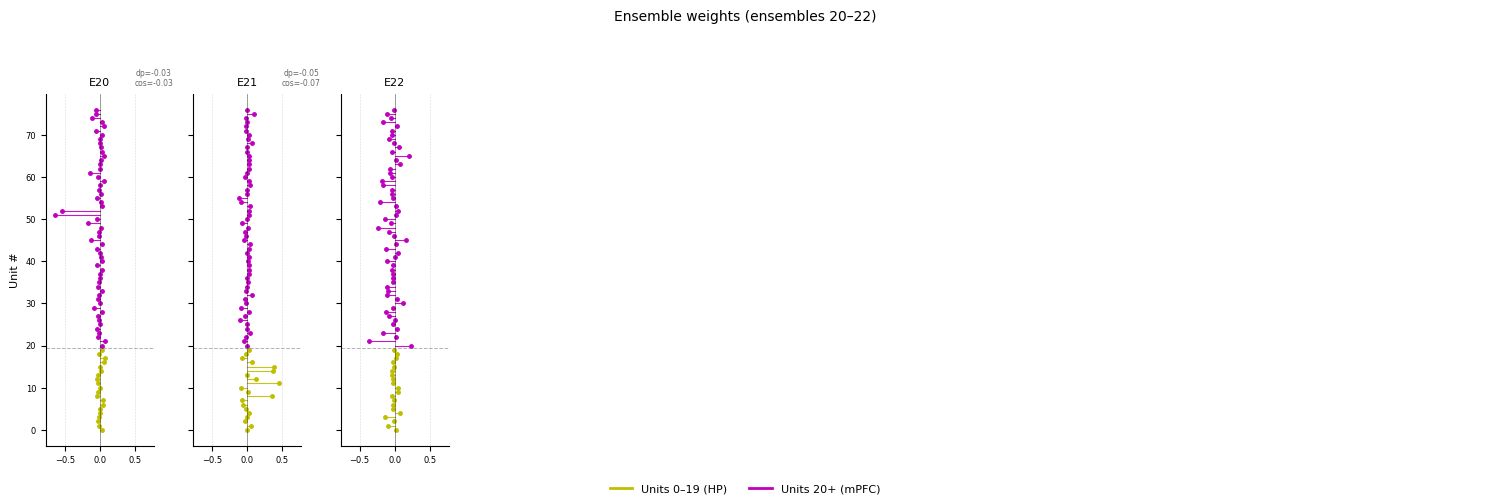

In [17]:
plt.close('all')

n_units, n_ensembles = ensambles.shape  # (77, 23)
n_cols = 10
n_figs = int(np.ceil(n_ensembles / n_cols))

# Colors: yellow for HP (first 20), magenta for mPFC (rest)
colors = np.array(['y'] * 20 + ['m'] * (n_units - 20))

y_pos = np.arange(n_units)

# shared x limits across all ensembles
xlim = np.max(np.abs(ensambles.values)) * 1.1
xlim = (-xlim, xlim)

# precompute dot products and cosine similarities between consecutive ensembles
ens_vals = ensambles.values  # (n_units, n_ensembles)
dot_products = []
cos_sims = []
for k in range(n_ensembles - 1):
    a, b = ens_vals[:, k], ens_vals[:, k + 1]
    dp = np.dot(a, b)
    cs = dp / (np.linalg.norm(a) * np.linalg.norm(b) + 1e-12)
    dot_products.append(dp)
    cos_sims.append(cs)

from matplotlib.lines import Line2D

for fig_idx in range(n_figs):
    start_ens = fig_idx * n_cols
    end_ens = min(start_ens + n_cols, n_ensembles)
    n_plots = end_ens - start_ens

    fig, axes = plt.subplots(
        nrows=1, ncols=n_cols,
        figsize=(n_cols * 1.5, 5),
        sharey=True, sharex=True
    )

    for col_i, ens_i in enumerate(range(start_ens, end_ens)):
        ax = axes[col_i]
        weights = ensambles.iloc[:, ens_i].values

        # horizontal stems
        for j in range(n_units):
            ax.plot([0, weights[j]], [y_pos[j], y_pos[j]],
                    color=colors[j], linewidth=0.8, alpha=0.9)
            ax.plot(weights[j], y_pos[j], 'o',
                    color=colors[j], markersize=2.5)

        ax.axvline(0, color='k', linewidth=0.5, alpha=0.5)
        ax.set_title(f'E{ens_i}', fontsize=8)
        ax.set_xlim(xlim)
        ax.tick_params(labelbottom=True, labelleft=(col_i == 0), labelsize=6)
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)
        ax.axhline(19.5, color='gray', linestyle='--', linewidth=0.7, alpha=0.6)
        ax.grid(axis='x', linestyle='--', linewidth=0.4, alpha=0.5)

        # annotate dot product & cosine similarity between this and next ensemble
        # only if next ensemble exists and is in the same figure
        if ens_i < n_ensembles - 1 and col_i < n_plots - 1:
            dp = dot_products[ens_i]
            cs = cos_sims[ens_i]
            # place annotation in the top margin between this ax and the next
            ax.annotate(
                f'dp={dp:.2f}\ncos={cs:.2f}',
                xy=(1.0, 1.0), xycoords='axes fraction',
                xytext=(0, 4), textcoords='offset points',
                ha='center', va='bottom', fontsize=5.5,
                color='dimgray',
                annotation_clip=False
            )

    # hide unused axes
    for col_i in range(n_plots, n_cols):
        axes[col_i].axis('off')

    axes[0].set_ylabel('Unit #', fontsize=8)

    legend_elements = [
        Line2D([0], [0], color='y', lw=2, label='Units 0–19 (HP)'),
        Line2D([0], [0], color='m', lw=2, label='Units 20+ (mPFC)'),
    ]
    fig.legend(handles=legend_elements, loc='lower center', ncol=2, fontsize=8, frameon=False)
    fig.suptitle(f'Ensemble weights (ensembles {start_ens}–{end_ens-1})', fontsize=10)
    plt.tight_layout(rect=[0, 0.04, 1, 0.95])
    plt.show()

In [18]:
ens_vals = ensambles.values  # (n_units, n_ensembles)

for k in range(ensambles.shape[1] - 1):
    a = ens_vals[:, k]
    b = ens_vals[:, k + 1]
    dp = np.dot(a, b)
    norm_a = np.linalg.norm(a)
    norm_b = np.linalg.norm(b)
    cs = dp / (norm_a * norm_b + 1e-12)
    
    print(f"E{k} vs E{k+1}:")
    print(f"  a[:5]    = {a[:5]}")
    print(f"  b[:5]    = {b[:5]}")
    print(f"  a nonzero: {np.count_nonzero(a)} / {len(a)}")
    print(f"  b nonzero: {np.count_nonzero(b)} / {len(b)}")
    print(f"  ||a||={norm_a:.4f}, ||b||={norm_b:.4f}")
    print(f"  dot(a,b) = {dp:.6f}")
    print(f"  cos_sim  = {cs:.6f}")
    print(f"  element-wise products: {(a * b)[:5]}")
    print()

E0 vs E1:
  a[:5]    = [-0.00762045  0.04565797  0.01003998  0.00431964  0.012085  ]
  b[:5]    = [-0.02657306  0.17550929 -0.01208609 -0.0007086   0.01140896]
  a nonzero: 77 / 77
  b nonzero: 77 / 77
  ||a||=0.8894, ||b||=0.8811
  dot(a,b) = 0.024696
  cos_sim  = 0.031513
  element-wise products: [ 2.02498781e-04  8.01339777e-03 -1.21344037e-04 -3.06091575e-06
  1.37877295e-04]

E1 vs E2:
  a[:5]    = [-0.02657306  0.17550929 -0.01208609 -0.0007086   0.01140896]
  b[:5]    = [-0.0103494   0.07743721 -0.00569134  0.02068163 -0.03182044]
  a nonzero: 77 / 77
  b nonzero: 77 / 77
  ||a||=0.8811, ||b||=0.9045
  dot(a,b) = -0.084064
  cos_sim  = -0.105483
  element-wise products: [ 2.75015189e-04  1.35909492e-02  6.87860634e-05 -1.46550877e-05
 -3.63038247e-04]

E2 vs E3:
  a[:5]    = [-0.0103494   0.07743721 -0.00569134  0.02068163 -0.03182044]
  b[:5]    = [ 0.01357252 -0.0046641  -0.00210859  0.03022321  0.0232852 ]
  a nonzero: 77 / 77
  b nonzero: 77 / 77
  ||a||=0.9045, ||b||=0.8972

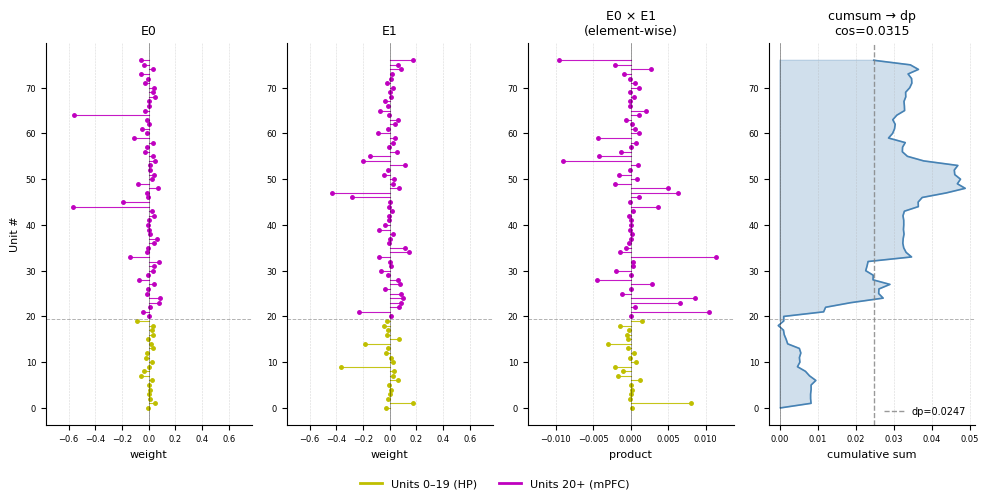

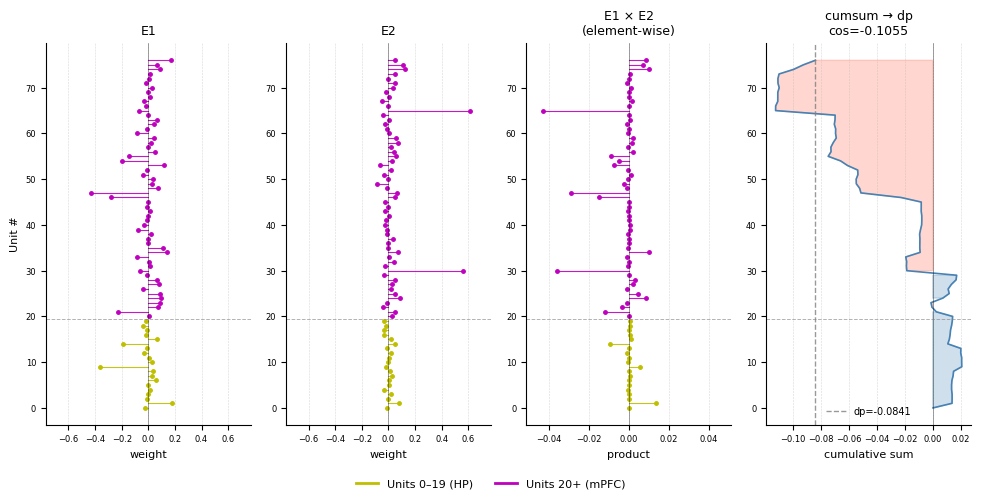

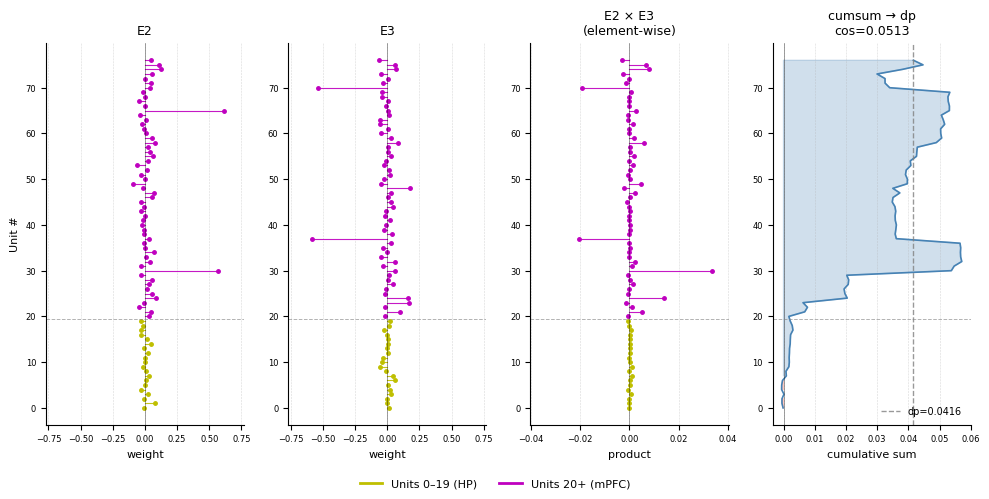

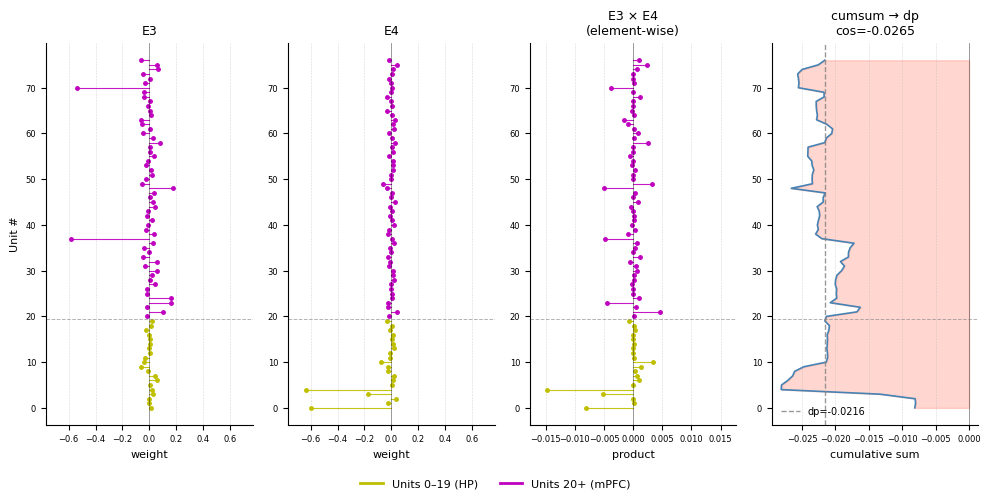

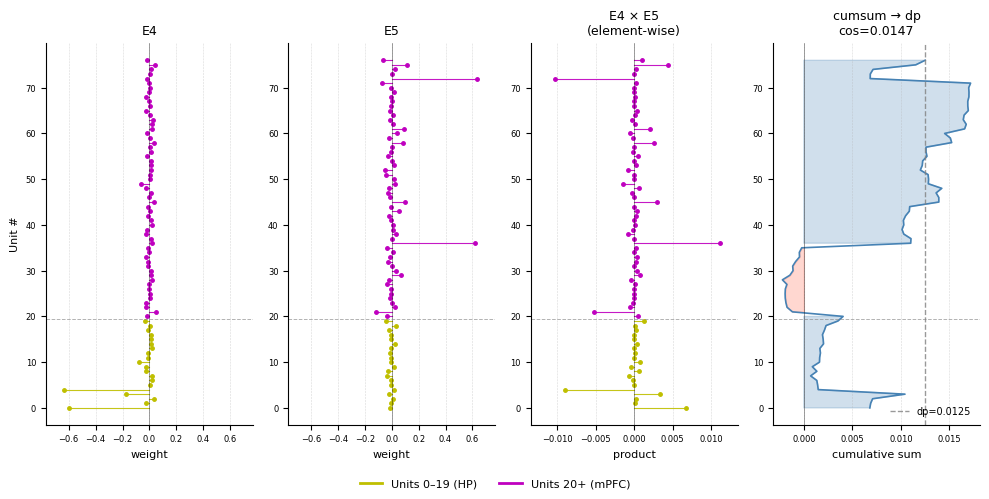

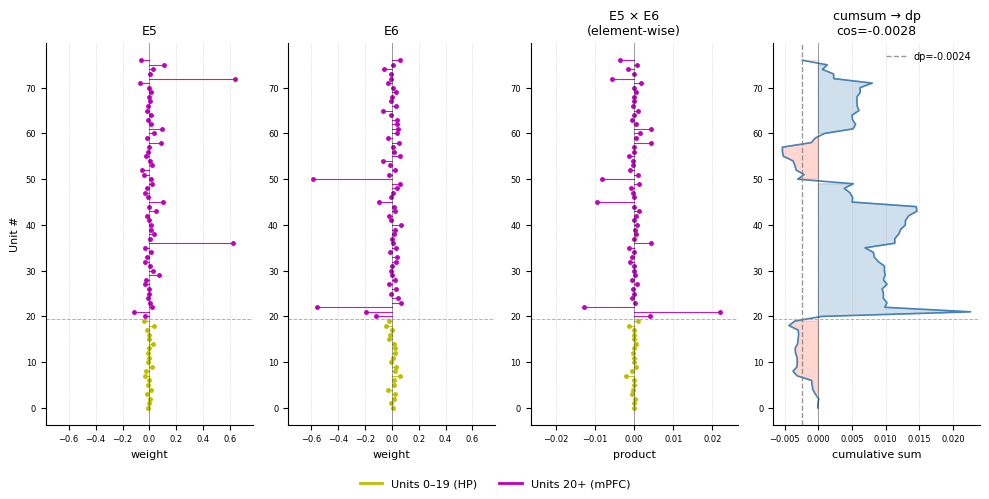

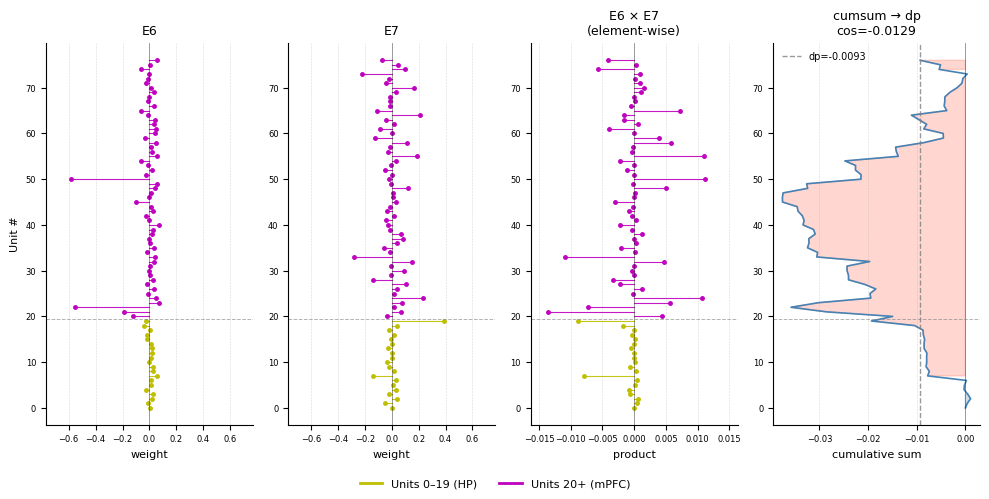

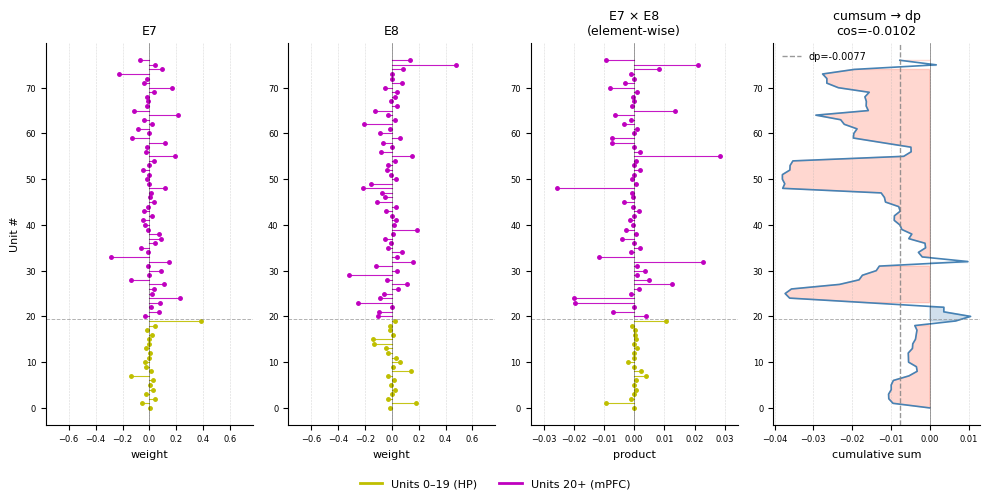

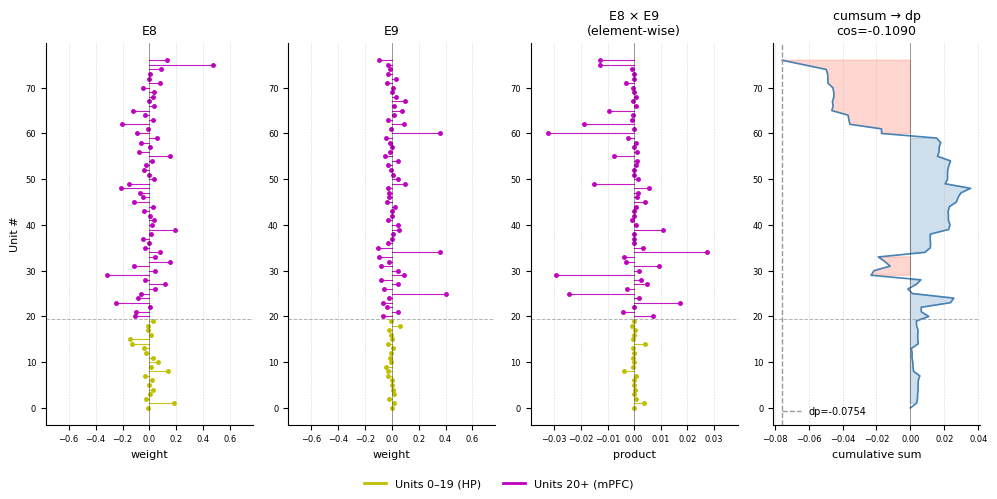

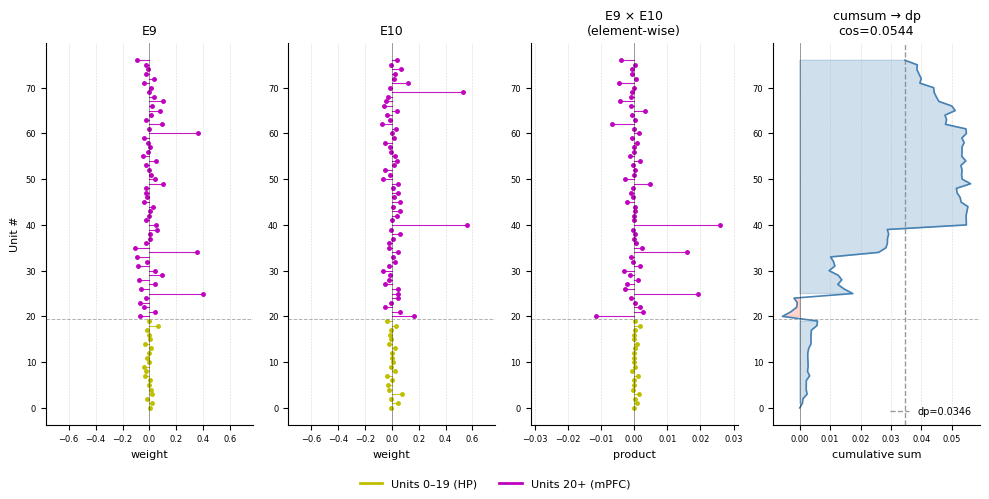

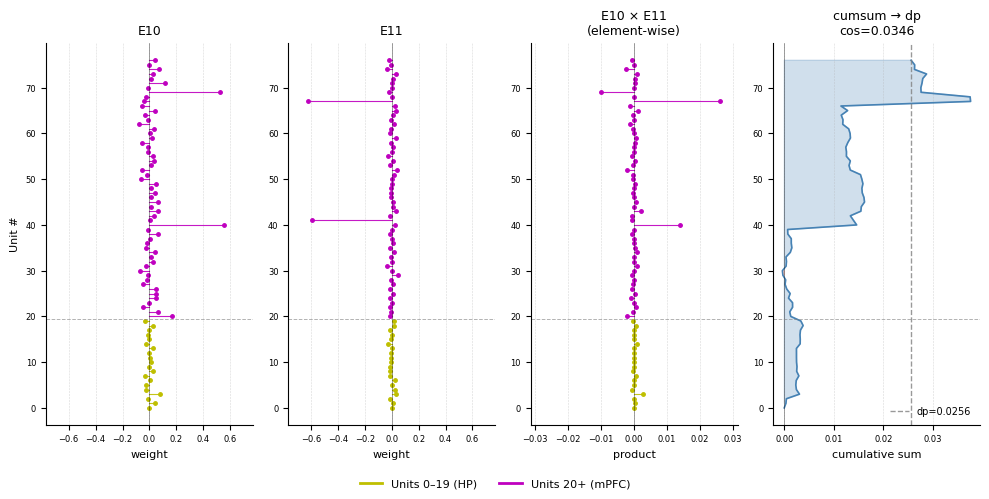

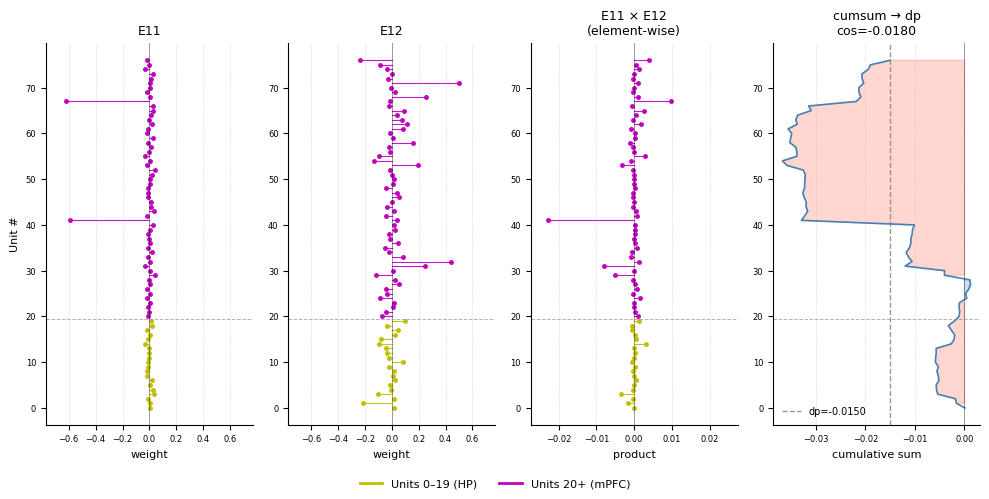

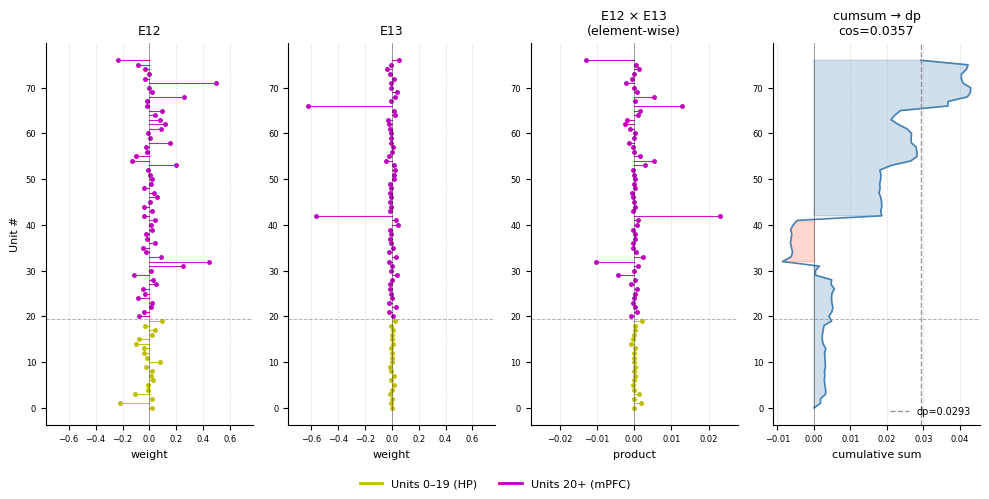

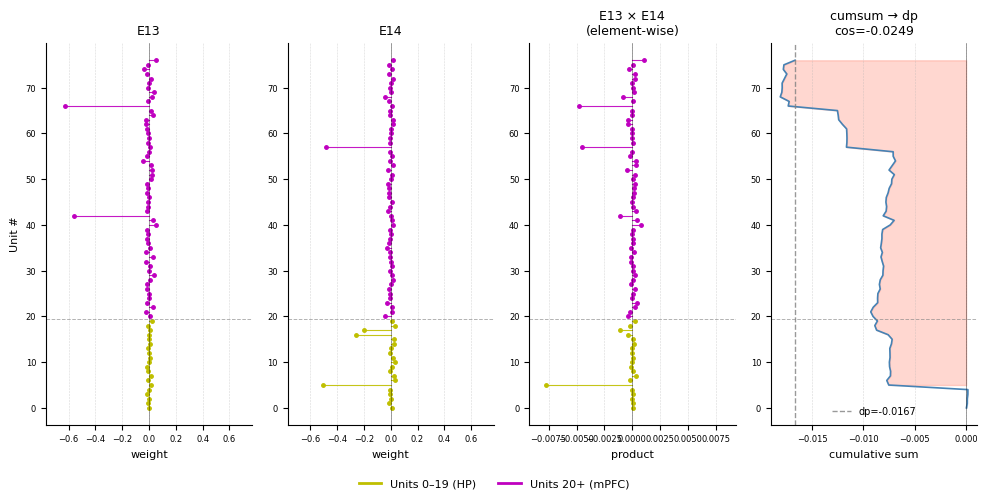

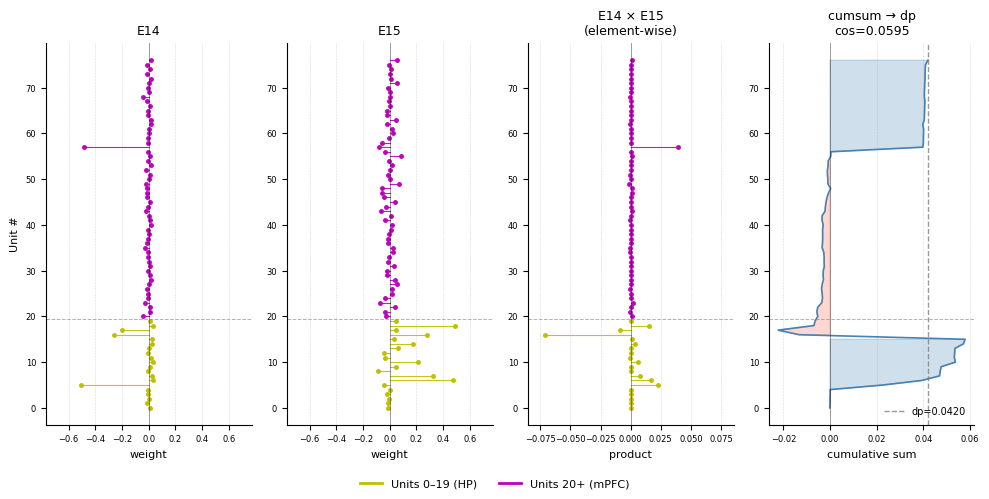

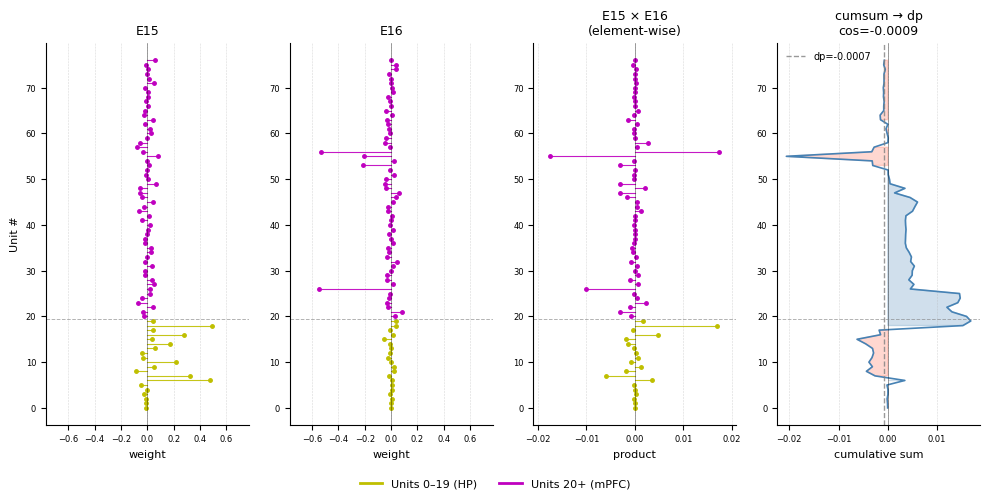

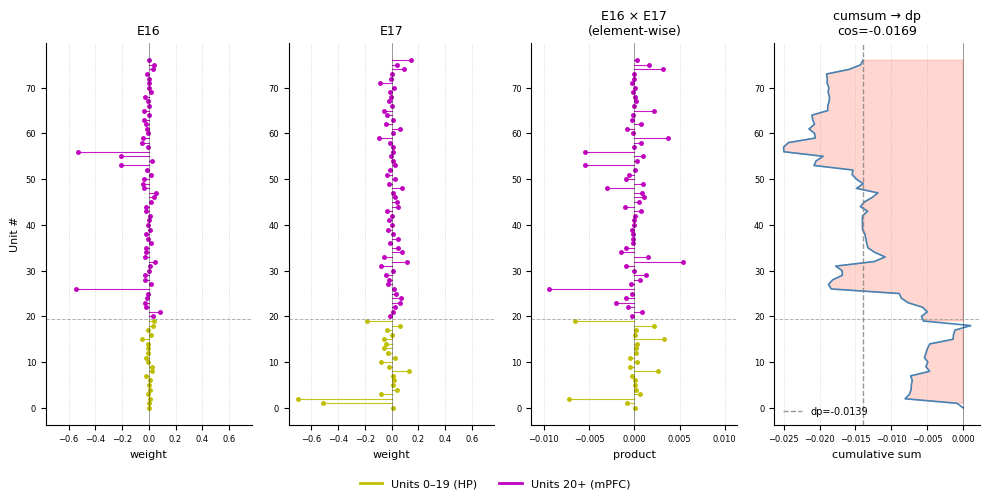

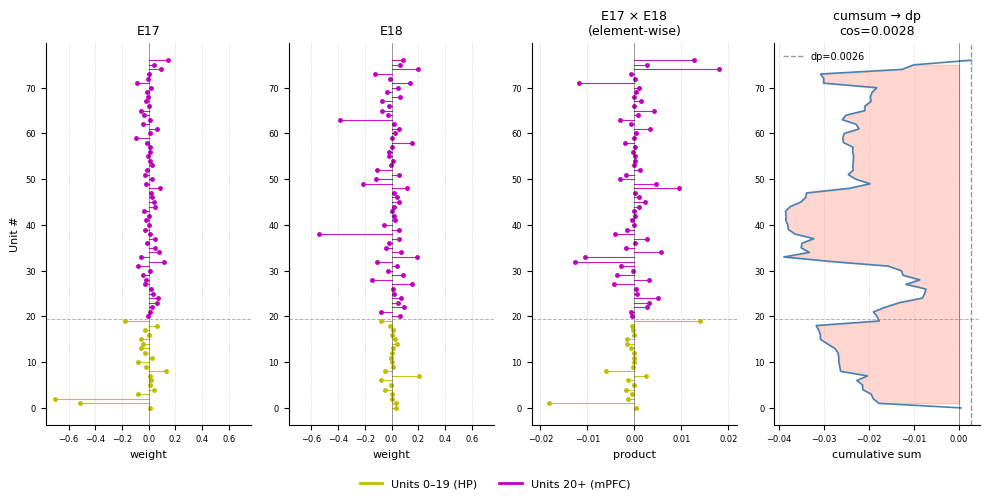

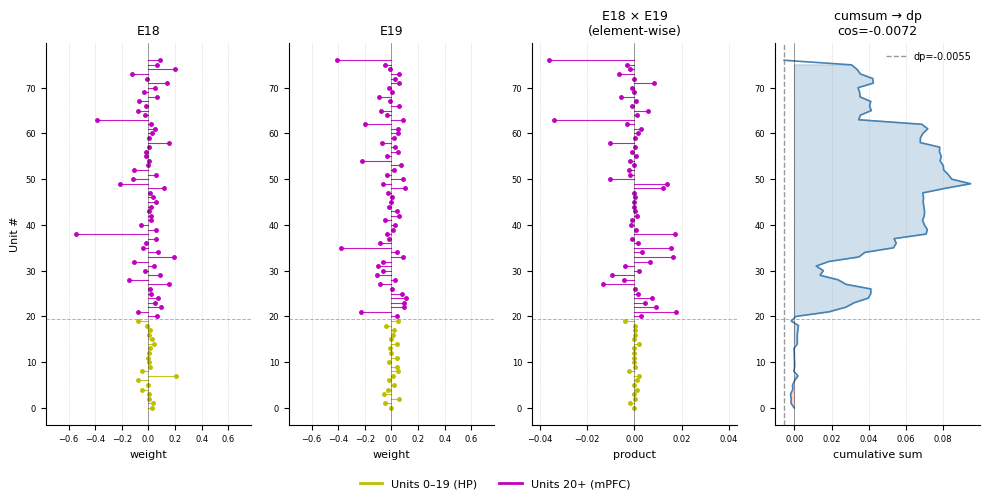

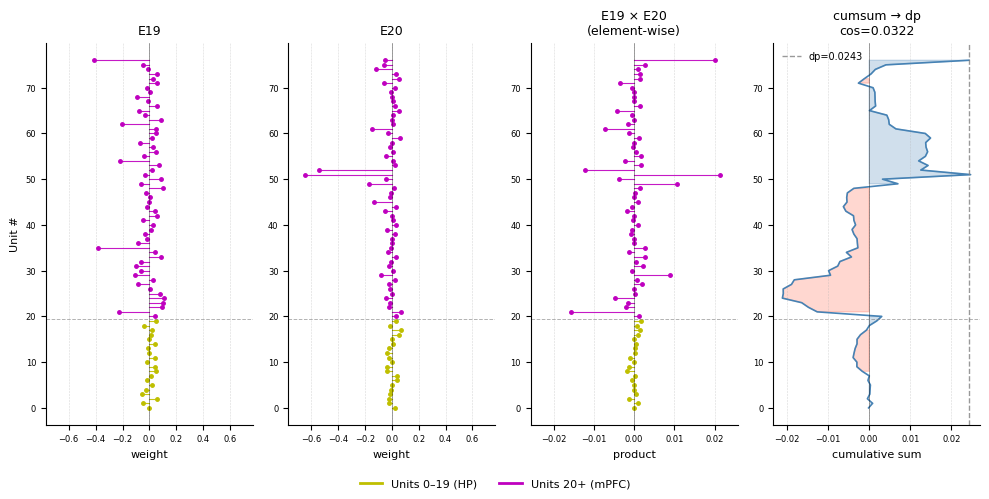

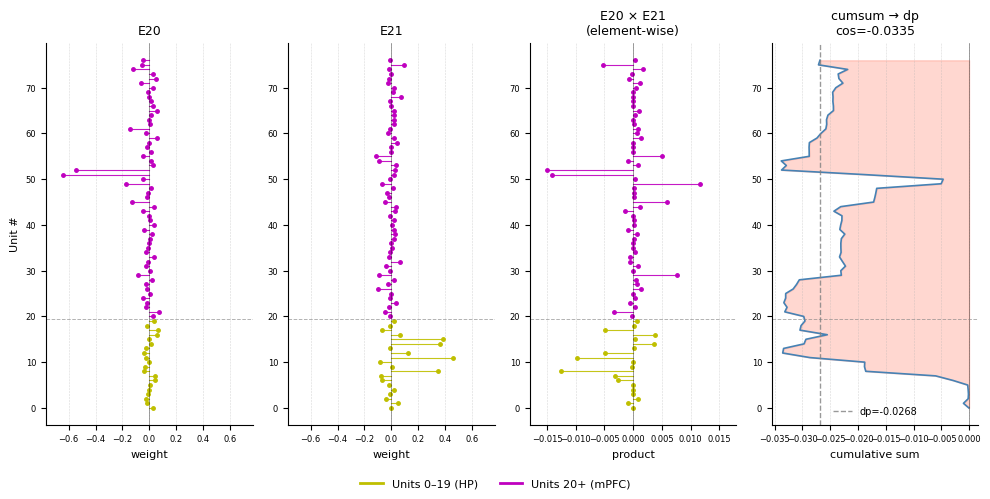

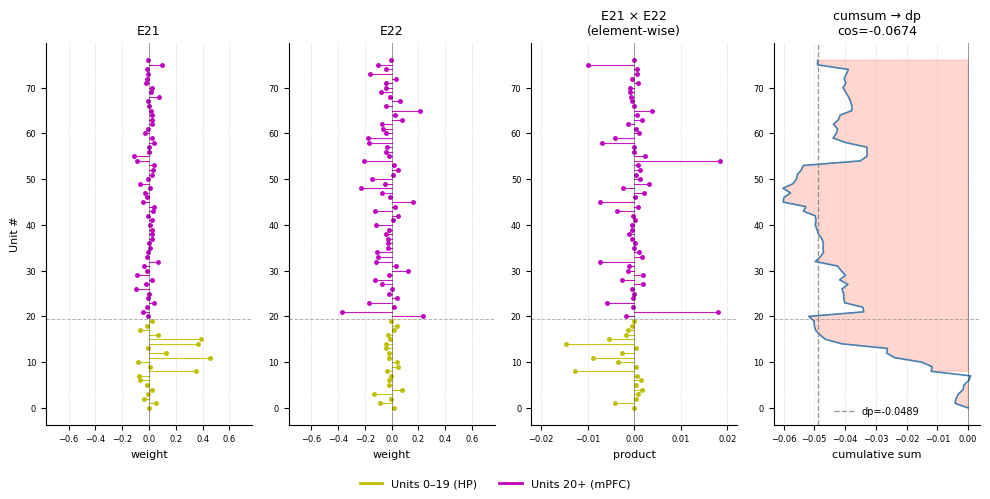

In [19]:
def plot_ensemble_pair(ensambles, ens_i, ens_j, n_hp=20):
    """
    4-panel plot for a pair of ensemble vectors:
      col 0: stem plot ensemble i
      col 1: stem plot ensemble j
      col 2: element-wise product a*b (stem)
      col 3: cumulative sum of a*b (line) — builds up the dot product
    """
    n_units = ensambles.shape[0]
    a = ensambles.iloc[:, ens_i].values
    b = ensambles.iloc[:, ens_j].values
    prod = a * b
    cumsum = np.cumsum(prod)

    colors = np.array(['y'] * n_hp + ['m'] * (n_units - n_hp))
    y_pos = np.arange(n_units)

    dp = np.dot(a, b)
    norm_a = np.linalg.norm(a)
    norm_b = np.linalg.norm(b)
    cs = dp / (norm_a * norm_b + 1e-12)

    fig, axes = plt.subplots(1, 4, figsize=(10, 5), sharey=False)

    xlim = np.max(np.abs(ensambles.values)) * 1.1

    # --- col 0 & 1: stem plots for each ensemble ---
    for ax_i, (vec, label) in enumerate([(a, f'E{ens_i}'), (b, f'E{ens_j}')]):
        ax = axes[ax_i]
        for j in range(n_units):
            ax.plot([0, vec[j]], [y_pos[j], y_pos[j]],
                    color=colors[j], linewidth=0.8, alpha=0.9)
            ax.plot(vec[j], y_pos[j], 'o', color=colors[j], markersize=2.5)
        ax.axvline(0, color='k', linewidth=0.5, alpha=0.5)
        ax.axhline(n_hp - 0.5, color='gray', linestyle='--', linewidth=0.7, alpha=0.6)
        ax.set_xlim(-xlim, xlim)
        ax.set_title(label, fontsize=9)
        ax.set_xlabel('weight', fontsize=8)
        ax.grid(axis='x', linestyle='--', linewidth=0.4, alpha=0.5)
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)
        ax.tick_params(labelsize=6)
    axes[0].set_ylabel('Unit #', fontsize=8)

    # --- col 2: element-wise product ---
    ax = axes[2]
    prod_lim = np.max(np.abs(prod)) * 1.2 or 0.01
    for j in range(n_units):
        ax.plot([0, prod[j]], [y_pos[j], y_pos[j]],
                color=colors[j], linewidth=0.8, alpha=0.9)
        ax.plot(prod[j], y_pos[j], 'o', color=colors[j], markersize=2.5)
    ax.axvline(0, color='k', linewidth=0.5, alpha=0.5)
    ax.axhline(n_hp - 0.5, color='gray', linestyle='--', linewidth=0.7, alpha=0.6)
    ax.set_xlim(-prod_lim, prod_lim)
    ax.set_title(f'E{ens_i} × E{ens_j}\n(element-wise)', fontsize=9)
    ax.set_xlabel('product', fontsize=8)
    ax.grid(axis='x', linestyle='--', linewidth=0.4, alpha=0.5)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.tick_params(labelsize=6)

    # --- col 3: cumulative sum (builds up dot product) ---
    ax = axes[3]
    ax.plot(cumsum, y_pos, color='steelblue', linewidth=1.2)
    ax.fill_betweenx(y_pos, 0, cumsum,
                     where=(cumsum >= 0), color='steelblue', alpha=0.25)
    ax.fill_betweenx(y_pos, 0, cumsum,
                     where=(cumsum < 0),  color='tomato',    alpha=0.25)
    ax.axvline(0,  color='k',    linewidth=0.5, alpha=0.5)
    ax.axvline(dp, color='gray', linewidth=1.0, linestyle='--', alpha=0.8,
               label=f'dp={dp:.4f}')
    ax.axhline(n_hp - 0.5, color='gray', linestyle='--', linewidth=0.7, alpha=0.6)
    ax.set_title(f'cumsum → dp\ncos={cs:.4f}', fontsize=9)
    ax.set_xlabel('cumulative sum', fontsize=8)
    ax.legend(fontsize=7, frameon=False)
    ax.grid(axis='x', linestyle='--', linewidth=0.4, alpha=0.5)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.tick_params(labelsize=6)

    from matplotlib.lines import Line2D
    legend_elements = [
        Line2D([0], [0], color='y', lw=2, label=f'Units 0–{n_hp-1} (HP)'),
        Line2D([0], [0], color='m', lw=2, label=f'Units {n_hp}+ (mPFC)'),
    ]
    fig.legend(handles=legend_elements, loc='lower center', ncol=2,
               fontsize=8, frameon=False)
    plt.tight_layout(rect=[0, 0.04, 1, 1])
    plt.show()


# plot all consecutive pairs
plt.close('all')
for k in range(ensambles.shape[1] - 1):
    plot_ensemble_pair(ensambles, k, k + 1)

In [20]:
# sn = '2024-11-14_16-40_rYL006_P1100_LinearTrackStop_21min'

ensamble_proj = analytics.get_analytics('ConcatenatedEnsambleProj40ms', 
                                        session_names=session_names).drop("to_ephys_timestamp", axis=1)
# make index instead
ensamble_proj.set_index(['session_id', 'from_ephys_timestamp', ], inplace=True)
ensamble_proj




2026-03-26 17:15:00,049|DEBUG|3597888|sessions_from_nas_parsing|sessionnames2fullfnames
	Inferring NAS paths for list of session names...
2026-03-26 17:15:00,052|DEBUG|3597888|sessions_from_nas_parsing|sessionlist_fullfnames_from_args
	Paradigm_ids: None, animal_ids: None, session_ids: None, from_date: None, to_date: None
	Merging 34 sessions

2026-03-26 17:15:00,052|DEBUG|3597888|analytics|get_analytics
	Processing ConcatenatedEnsambleProj40ms, for n=34 sessions


/mnt/slow/BMI/VirtualReality/SpatialSequenceLearning/RUN_rYL006/rYL006_P1100/2024-11-14_15-01_rYL006_P1100_LinearTrackStop_30min/../../animal_analytics/ConcatenatedEnsambleProj40ms.parquet


2026-03-26 17:15:00,465|INFO|3597888|analytics|get_analytics
	Loaded animal-level analytic `ConcatenatedEnsambleProj40ms` last modified on 2026-03-23T12:48:40.955117


Assembly001  Assembly002  Assembly003  \
session_id       from_ephys_timestamp                                          
2024-11-14_16-40 0                       -0.003749     0.188389     0.596589   
                 40000                   -0.008523    -0.084321     0.760840   
                 80000                   -0.008068     0.437550     0.508324   
                 120000                   0.060204     0.605307     0.464744   
                 160000                   0.070604     0.039394     0.683770   
...                                            ...          ...          ...   
2025-01-27_13-39 4435920000              -0.032500    -0.257642    -0.164107   
                 4435960000               0.363482     0.408435    -0.432517   
                 4436000000               0.583994     0.039138    -0.462426   
                 4436040000              -0.100442     1.060829     0.846502   
                 4436080000               0.175562    -0.096601     0.352214   

                                       Assembly004  Assembly005  Assembly006  \
session_id       from_ephys_timestamp                                          
2024-11-14_16-40 0                       -0.271849     0.009416    -0.041533   
                 40000                   -0.239982     0.010639     0.004561   
                 80000                   -0.305987     0.002827    -0.072981   
                 120000                  -0.253230     0.023734    -0.014145   
                 160000                  -0.258118     0.018634    -0.010309   
...                                            ...          ...          ...   
2025-01-27_13-39 4435920000               0.211492     0.075438     0.326656   
                 4435960000              -0.062093     0.016409     0.162183   
                 4436000000              -0.250421    -0.027796     0.410473   
                 4436040000               0.297454     0.105284     0.240791   
                 4436080000              -0.132666     0.032783    -0.016105   

                                       Assembly007  Assembly008  Assembly009  \
session_id       from_ephys_timestamp                                          
2024-11-14_16-40 0                        0.201716    -0.013231    -0.221973   
                 40000                    0.117536    -0.015045    -0.087302   
                 80000                    0.275745    -0.011749    -0.263305   
                 120000                   0.085099    -0.089253    -0.131345   
                 160000                  -0.184203    -0.036144    -0.025537   
...                                            ...          ...          ...   
2025-01-27_13-39 4435920000              -0.395579     0.014455     1.124471   
                 4435960000               0.122090    -0.091718     0.393538   
                 4436000000              -0.313297     0.151307    -0.448495   
                 4436040000              -0.437525    -0.171747    -0.255950   
                 4436080000               0.019440    -0.138063     0.180330   

                                       Assembly010  ...  Assembly014  \
session_id       from_ephys_timestamp               ...                
2024-11-14_16-40 0                       -0.271392  ...     0.079650   
                 40000                   -0.110956  ...     0.078771   
                 80000                   -0.471948  ...     0.075393   
                 120000                  -0.151873  ...     0.012177   
                 160000                  -0.032442  ...     0.040270   
...                                            ...  ...          ...   
2025-01-27_13-39 4435920000              -0.254890  ...    -0.044534   
                 4435960000              -0.125032  ...    -0.005718   
                 4436000000              -0.199899  ...     0.047805   
                 4436040000              -0.105051  ...     0.041310   
                 4436080000              -0.007673  

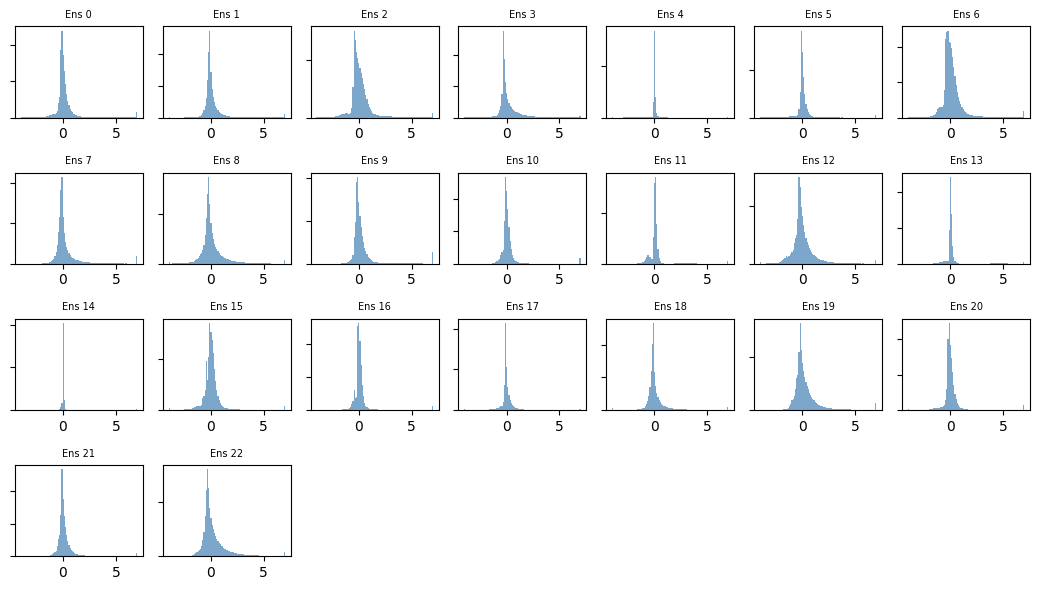

In [21]:
plt.close('all')

# Get number of ensembles
n_ensembles = ensamble_proj.shape[1]

# Calculate grid dimensions (7 columns)
n_cols = 7
n_rows = int(np.ceil(n_ensembles / n_cols))

# Create figure with subplots
fig, axes = plt.subplots(n_rows, n_cols, figsize=(n_cols * 1.5, n_rows * 1.5), squeeze=False, )
axes = axes.flatten()

for i in range(n_ensembles):
    ax = axes[i]
    ax.hist(np.clip(ensamble_proj.iloc[:, i], -4, 7), bins=100, color='steelblue', alpha=0.7, range=(-4, 7))
    ax.tick_params(labelleft=False)
    ax.set_title(f'Ens {i}', fontsize=7)

# Hide unused subplots
for i in range(n_ensembles, len(axes)):
    axes[i].axis('off')

plt.tight_layout()
plt.show()


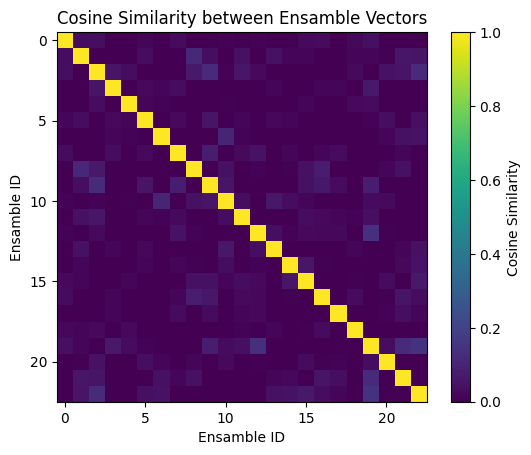

In [22]:
# ensamble vectors are orthogonal 

plt.close('all')

# calculate angles between column vectors
from sklearn.metrics.pairwise import cosine_similarity
cos_sim = cosine_similarity(ensambles.T)
im = plt.imshow(cos_sim, cmap='viridis', vmin=0, vmax=1)
plt.colorbar(im, label='Cosine Similarity')
plt.title('Cosine Similarity between Ensamble Vectors')
plt.xlabel('Ensamble ID')
plt.ylabel('Ensamble ID')
plt.show()


2026-03-26 17:15:03,019|DEBUG|3597888|sessions_from_nas_parsing|sessionnames2fullfnames
	Inferring NAS paths for list of session names...
2026-03-26 17:15:03,021|DEBUG|3597888|sessions_from_nas_parsing|sessionlist_fullfnames_from_args
	Paradigm_ids: None, animal_ids: None, session_ids: None, from_date: None, to_date: None
	Merging 34 sessions

2026-03-26 17:15:03,021|DEBUG|3597888|analytics|get_analytics
	Processing ConcatenatedPCs40ms, for n=34 sessions
2026-03-26 17:15:03,027|INFO|3597888|analytics|get_analytics
	Loaded animal-level analytic `ConcatenatedPCs40ms` last modified on 2025-07-23T16:34:06.796403


/mnt/slow/BMI/VirtualReality/SpatialSequenceLearning/RUN_rYL006/rYL006_P1100/2024-11-14_15-01_rYL006_P1100_LinearTrackStop_30min/../../animal_analytics/ConcatenatedPCs40ms.parquet
leaf order for rows: [ 4 18 13  6 10  0  1  8 14 15 12 19 22  5 20 16 21 11  7  2  9  3 17]
leaf order for columns: [16  2 28 45 25 13 53 11  9 55 10 20 60 37  1 64 23 43 69 24 72 31 71 29
 67 59 39 75 35 63 54 73 50 21 41 15 14 49 65 34 40 42 44 68 76 22 38 26
 27 74  4 52 47 48 66  3 58 30 32  5 18 17 57 33  0 36  7 61 51 70  6 56
 19 62 12  8 46]


Text(0.5, 1.0, 'Cosine Similarity between Ensambles and PCs')

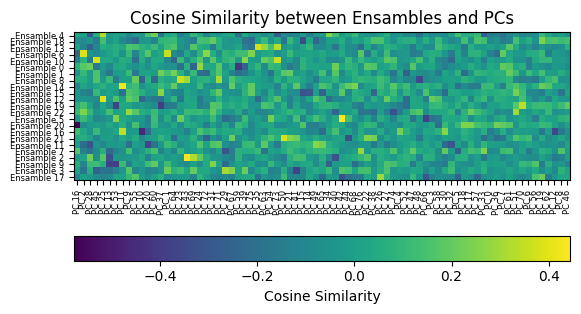

In [23]:
# THE ICA rotates PCs significatnly. They remain orthonogal, but are very dissimilar to PCs


# get PCs (inputs to ensemble detection before ICA)
pcs = analytics.get_analytics('ConcatenatedPCs40ms', session_names=session_names).iloc[:, :-2]
pcs

results = np.zeros((ensambles.shape[1], pcs.shape[1]))
for i, ens in enumerate(ensambles.columns):
    cos_sim = cosine_similarity(pcs, ensambles[ens].values.reshape(1, -1))
    results[i, :] = cos_sim[:, 0]
    
# cluster rows (ensambles)
from scipy.cluster.hierarchy import linkage, leaves_list
Z = linkage(results, method='average', metric='euclidean')
row_leaf_order = leaves_list(Z)
print("leaf order for rows:", row_leaf_order)
results = results[row_leaf_order, :]

# same for columns (PCs)
Z = linkage(results.T, method='average', metric='euclidean')
col_leaf_order = leaves_list(Z)
print("leaf order for columns:", col_leaf_order)
results = results[:, col_leaf_order]

plt.close('all')
fig = plt.Figure(figsize=(20, 18))
im = plt.imshow(results, cmap='viridis')
plt.colorbar(im, label='Cosine Similarity', orientation='horizontal')

# axis labels
plt.xticks(ticks=np.arange(pcs.shape[1]), labels=[f'PC {i}' for i in col_leaf_order], rotation=90, fontsize=6)
plt.yticks(ticks=np.arange(ensambles.shape[1]), labels=[f'Ensamble {i}' for i in row_leaf_order], fontsize=6)
plt.title('Cosine Similarity between Ensambles and PCs')



Next session index: 0, session id: 2024-11-14_16-40
Next session index: 32200, session id: 2024-11-15_15-48
Next session index: 85792, session id: 2024-11-20_17-46
Next session index: 119626, session id: 2024-11-21_17-22
Next session index: 158431, session id: 2024-11-25_16-25
Next session index: 185890, session id: 2024-11-26_16-39
Next session index: 224103, session id: 2024-11-28_17-41
Next session index: 270222, session id: 2024-12-02_16-09
Next session index: 313055, session id: 2024-12-03_16-23
Next session index: 358155, session id: 2024-12-04_18-06
Next session index: 403950, session id: 2024-12-06_16-49
Next session index: 442421, session id: 2024-12-09_17-45
Next session index: 481647, session id: 2024-12-10_17-20
Next session index: 528054, session id: 2024-12-11_17-42
Next session index: 573154, session id: 2024-12-12_16-13
Next session index: 613488, session id: 2024-12-13_17-10
Next session index: 659650, session id: 2025-01-14_18-08
Next session index: 705001, session id

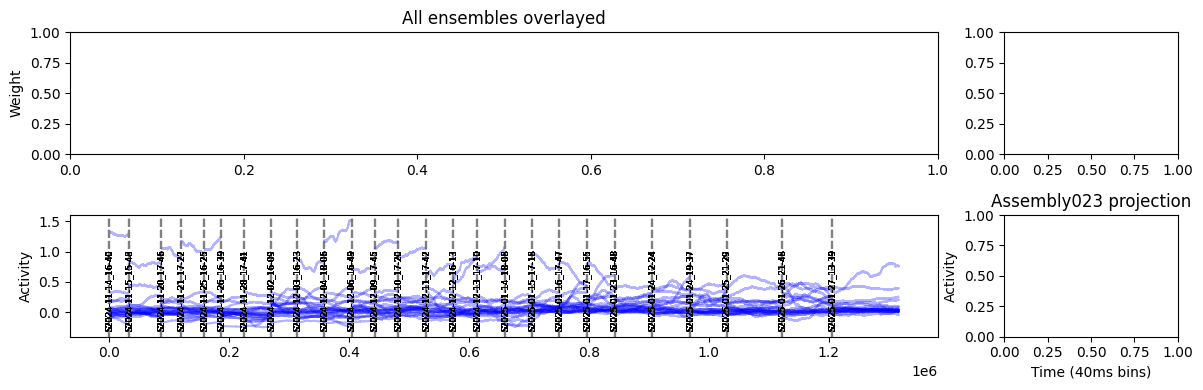

In [24]:
fig, ax = plt.subplots(ncols=2, nrows=2, figsize=(12, 4), width_ratios=(5,1))
ax = ax.flatten()
for i in ensamble_proj.columns:
    # fig, ax = plt.subplots(ncols=2, nrows=2, figsize=(29, 6), width_ratios=(15,1))
    ax[0].set_title(f'All ensembles overlayed')
    # ax[0].set_xlabel('Neurons')
    ax[0].set_ylabel('Weight')
    
    
    # markerline1 = ax[0].stem(np.arange(20), ensambles[i].iloc[:20], label=f'{i}, HP', linefmt='y-', markerfmt='yo', basefmt=" ")
    # markerline2 = ax[0].stem(np.arange(20, ensambles.shape[0]), ensambles[i].iloc[20:], label=f'{i}, mPFC', linefmt='m-', markerfmt='mo', basefmt=" ")
    
    # Draw circles only for high weight
    # thr = .2
    # x = np.arange(ensambles.shape[0])[np.abs(ensambles[i]) > thr]
    # ax[0].scatter(x, ensambles[i][np.abs(ensambles[i]) > thr], s=80, facecolors='none', 
    #               edgecolors='k', linewidths=2, zorder=3, label='Otsu thresh.')

    # lims = (-.45, .45)
    # ax[0].set_ylim(lims)
    # ax[0].legend(fontsize=8)

    # ax[1].hist(np.abs(ensambles[i]), bins=10, label=f'{i} Activity', color='gray', alpha=0.7)
    # ax[1].axvline(x=thr, color='k')
    # ax[1].set_xlabel("abs. weight")
    # ax[1].set_ylabel("Count")

    plt.gca().set_title(f'{i} projection')
    plt.gca().set_xlabel('Time (40ms bins)')
    plt.gca().set_ylabel('Activity')
    # ax[2].set_ylim(-.8,.8)
    
    # real = np.clip(ensamble_proj[i], -5, 5)
    # ax[2].scatter(np.arange(len(real)), real.values, label=f'{i} Activity (25 ms)', color='red', alpha=0.04, s=1)
    
    activity_lims = (-.4, 1.6, )
    
    smoothed = np.clip(ensamble_proj[i], -3, 3).groupby(level='session_id').rolling(window=25*60*15, center=True, min_periods=25*60*8 ).mean().values
    ax[2].plot(smoothed, label=f'{i} Activity (15 min mean)', color='blue', alpha=.3)

    # smoothed = np.clip(ensamble_proj[i], -3, 3).groupby(level='session_id').rolling(window=25*30, center=True, min_periods=1 ).mean().values
    # ax[2].plot(smoothed, label=f'{i} Activity (30 s mean)', color='blue', alpha=.3, linewidth=0.5)

    # if i == 0:
    sample_cnt = 0
    for s_id in ensamble_proj.index.unique(level='session_id'):
        print(f"Next session index: {sample_cnt}, session id: {s_id}")
        # kwargs = {'label': 'next session'} if sample_cnt == 0 else {}
        ax[2].axvline(x=sample_cnt, color='gray', linestyle='--', alpha=0.2,)
        ax[2].annotate(f'S{s_id:02}', xy=(sample_cnt, activity_lims[0]), xytext=(sample_cnt, activity_lims[0]+.1),
                    fontsize=6, color='black', rotation=90, va='bottom', ha='center')
        sample_cnt += len(ensamble_proj.loc[s_id])
    ax[2].set_ylim(activity_lims)
    ax[2].set_ylabel('Activity')
    # ax[2].legend(fontsize=8)
    # plot the ensemble projection histogram
    # med = np.nanmedian(ensamble_proj[i])
    # ax[3].hist(np.clip(ensamble_proj[i], -1.5, 2.5), bins=50, color='steelblue', alpha=0.7, label=f"Median: {med:.2f}")
    # ax[3].vlines(activity_lims, ymin=0, ymax=ax[3].get_ylim()[1], color='k', linestyles='--', alpha=.3)
    # ax[3].set_ylabel('Count')
    # ax[3].legend(fontsize=6)
    # ax[3].set_xlim(-1.6, 2.6)
    # break
plt.tight_layout()
plt.show()


Next session index: 0, session id: 2024-11-14_16-40
Next session index: 32200, session id: 2024-11-15_15-48
Next session index: 85792, session id: 2024-11-20_17-46
Next session index: 119626, session id: 2024-11-21_17-22
Next session index: 158431, session id: 2024-11-25_16-25
Next session index: 185890, session id: 2024-11-26_16-39
Next session index: 224103, session id: 2024-11-28_17-41
Next session index: 270222, session id: 2024-12-02_16-09
Next session index: 313055, session id: 2024-12-03_16-23
Next session index: 358155, session id: 2024-12-04_18-06
Next session index: 403950, session id: 2024-12-06_16-49
Next session index: 442421, session id: 2024-12-09_17-45
Next session index: 481647, session id: 2024-12-10_17-20
Next session index: 528054, session id: 2024-12-11_17-42
Next session index: 573154, session id: 2024-12-12_16-13
Next session index: 613488, session id: 2024-12-13_17-10
Next session index: 659650, session id: 2025-01-14_18-08
Next session index: 705001, session id

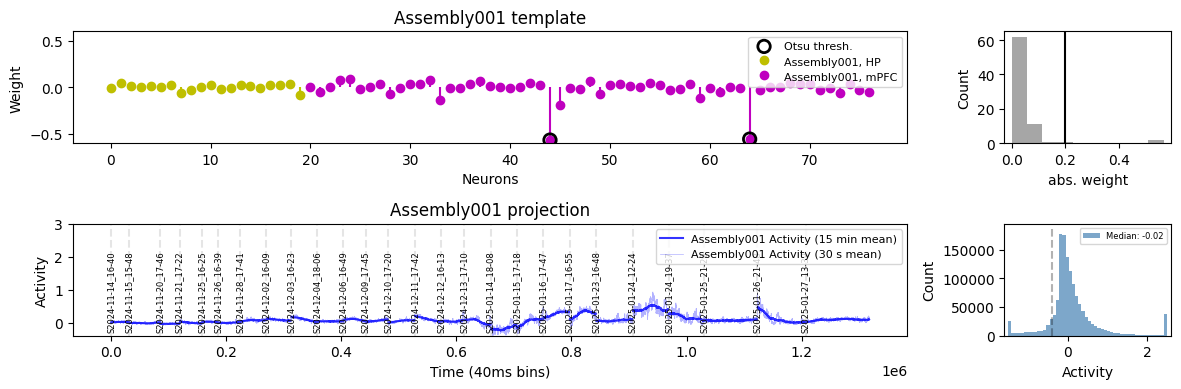

Next session index: 0, session id: 2024-11-14_16-40
Next session index: 32200, session id: 2024-11-15_15-48
Next session index: 85792, session id: 2024-11-20_17-46
Next session index: 119626, session id: 2024-11-21_17-22
Next session index: 158431, session id: 2024-11-25_16-25
Next session index: 185890, session id: 2024-11-26_16-39
Next session index: 224103, session id: 2024-11-28_17-41
Next session index: 270222, session id: 2024-12-02_16-09
Next session index: 313055, session id: 2024-12-03_16-23
Next session index: 358155, session id: 2024-12-04_18-06
Next session index: 403950, session id: 2024-12-06_16-49
Next session index: 442421, session id: 2024-12-09_17-45
Next session index: 481647, session id: 2024-12-10_17-20
Next session index: 528054, session id: 2024-12-11_17-42
Next session index: 573154, session id: 2024-12-12_16-13
Next session index: 613488, session id: 2024-12-13_17-10
Next session index: 659650, session id: 2025-01-14_18-08
Next session index: 705001, session id

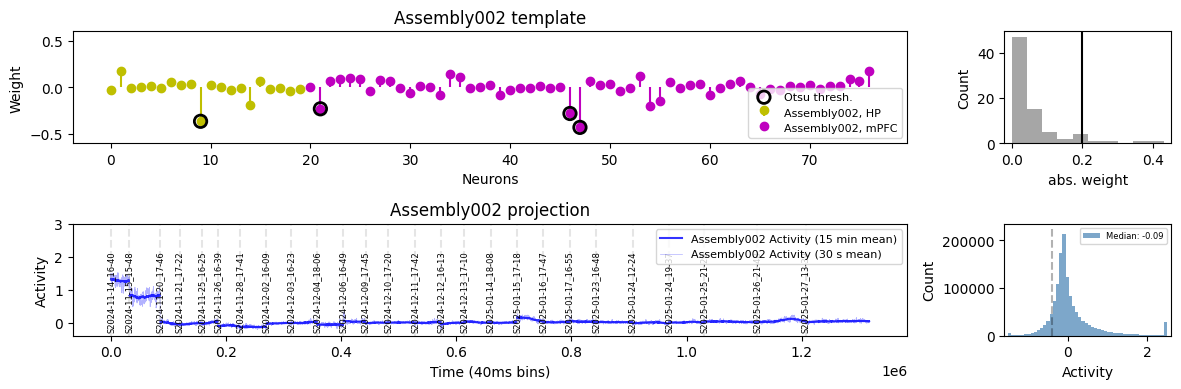

Next session index: 0, session id: 2024-11-14_16-40
Next session index: 32200, session id: 2024-11-15_15-48
Next session index: 85792, session id: 2024-11-20_17-46
Next session index: 119626, session id: 2024-11-21_17-22
Next session index: 158431, session id: 2024-11-25_16-25
Next session index: 185890, session id: 2024-11-26_16-39
Next session index: 224103, session id: 2024-11-28_17-41
Next session index: 270222, session id: 2024-12-02_16-09
Next session index: 313055, session id: 2024-12-03_16-23
Next session index: 358155, session id: 2024-12-04_18-06
Next session index: 403950, session id: 2024-12-06_16-49
Next session index: 442421, session id: 2024-12-09_17-45
Next session index: 481647, session id: 2024-12-10_17-20
Next session index: 528054, session id: 2024-12-11_17-42
Next session index: 573154, session id: 2024-12-12_16-13
Next session index: 613488, session id: 2024-12-13_17-10
Next session index: 659650, session id: 2025-01-14_18-08
Next session index: 705001, session id

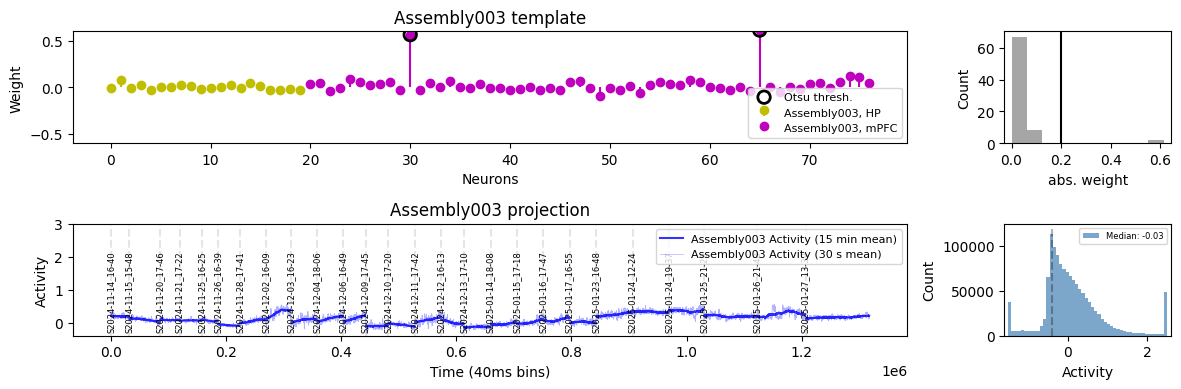

Next session index: 0, session id: 2024-11-14_16-40
Next session index: 32200, session id: 2024-11-15_15-48
Next session index: 85792, session id: 2024-11-20_17-46
Next session index: 119626, session id: 2024-11-21_17-22
Next session index: 158431, session id: 2024-11-25_16-25
Next session index: 185890, session id: 2024-11-26_16-39
Next session index: 224103, session id: 2024-11-28_17-41
Next session index: 270222, session id: 2024-12-02_16-09
Next session index: 313055, session id: 2024-12-03_16-23
Next session index: 358155, session id: 2024-12-04_18-06
Next session index: 403950, session id: 2024-12-06_16-49
Next session index: 442421, session id: 2024-12-09_17-45
Next session index: 481647, session id: 2024-12-10_17-20
Next session index: 528054, session id: 2024-12-11_17-42
Next session index: 573154, session id: 2024-12-12_16-13
Next session index: 613488, session id: 2024-12-13_17-10
Next session index: 659650, session id: 2025-01-14_18-08
Next session index: 705001, session id

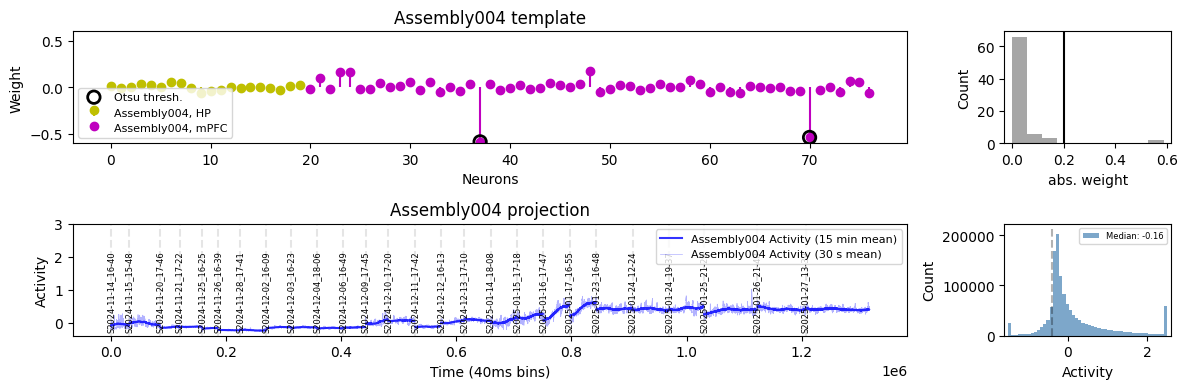

Next session index: 0, session id: 2024-11-14_16-40
Next session index: 32200, session id: 2024-11-15_15-48
Next session index: 85792, session id: 2024-11-20_17-46
Next session index: 119626, session id: 2024-11-21_17-22
Next session index: 158431, session id: 2024-11-25_16-25
Next session index: 185890, session id: 2024-11-26_16-39
Next session index: 224103, session id: 2024-11-28_17-41
Next session index: 270222, session id: 2024-12-02_16-09
Next session index: 313055, session id: 2024-12-03_16-23
Next session index: 358155, session id: 2024-12-04_18-06
Next session index: 403950, session id: 2024-12-06_16-49
Next session index: 442421, session id: 2024-12-09_17-45
Next session index: 481647, session id: 2024-12-10_17-20
Next session index: 528054, session id: 2024-12-11_17-42
Next session index: 573154, session id: 2024-12-12_16-13
Next session index: 613488, session id: 2024-12-13_17-10
Next session index: 659650, session id: 2025-01-14_18-08
Next session index: 705001, session id

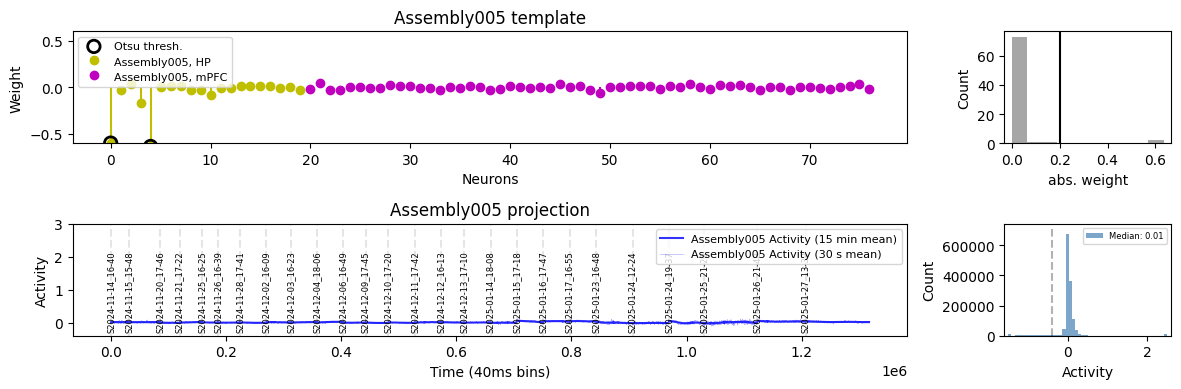

Next session index: 0, session id: 2024-11-14_16-40
Next session index: 32200, session id: 2024-11-15_15-48
Next session index: 85792, session id: 2024-11-20_17-46
Next session index: 119626, session id: 2024-11-21_17-22
Next session index: 158431, session id: 2024-11-25_16-25
Next session index: 185890, session id: 2024-11-26_16-39
Next session index: 224103, session id: 2024-11-28_17-41
Next session index: 270222, session id: 2024-12-02_16-09
Next session index: 313055, session id: 2024-12-03_16-23
Next session index: 358155, session id: 2024-12-04_18-06
Next session index: 403950, session id: 2024-12-06_16-49
Next session index: 442421, session id: 2024-12-09_17-45
Next session index: 481647, session id: 2024-12-10_17-20
Next session index: 528054, session id: 2024-12-11_17-42
Next session index: 573154, session id: 2024-12-12_16-13
Next session index: 613488, session id: 2024-12-13_17-10
Next session index: 659650, session id: 2025-01-14_18-08
Next session index: 705001, session id

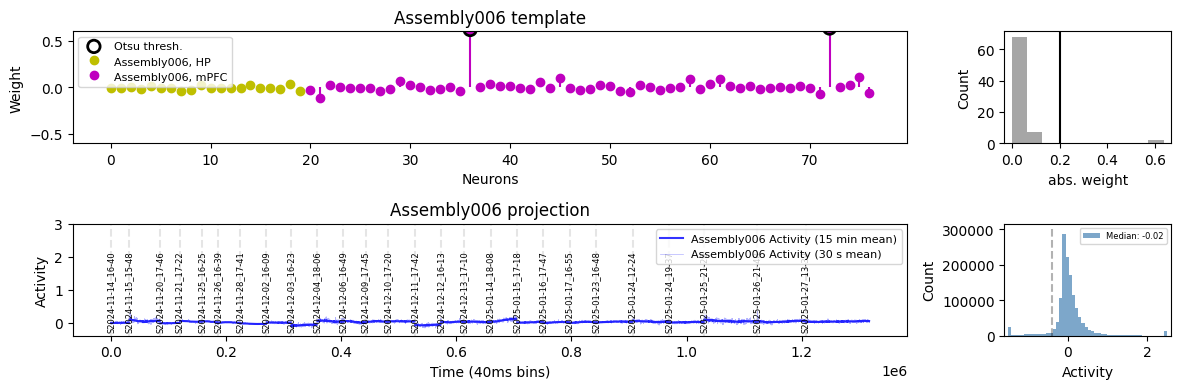

Next session index: 0, session id: 2024-11-14_16-40
Next session index: 32200, session id: 2024-11-15_15-48
Next session index: 85792, session id: 2024-11-20_17-46
Next session index: 119626, session id: 2024-11-21_17-22
Next session index: 158431, session id: 2024-11-25_16-25
Next session index: 185890, session id: 2024-11-26_16-39
Next session index: 224103, session id: 2024-11-28_17-41
Next session index: 270222, session id: 2024-12-02_16-09
Next session index: 313055, session id: 2024-12-03_16-23
Next session index: 358155, session id: 2024-12-04_18-06
Next session index: 403950, session id: 2024-12-06_16-49
Next session index: 442421, session id: 2024-12-09_17-45
Next session index: 481647, session id: 2024-12-10_17-20
Next session index: 528054, session id: 2024-12-11_17-42
Next session index: 573154, session id: 2024-12-12_16-13
Next session index: 613488, session id: 2024-12-13_17-10
Next session index: 659650, session id: 2025-01-14_18-08
Next session index: 705001, session id

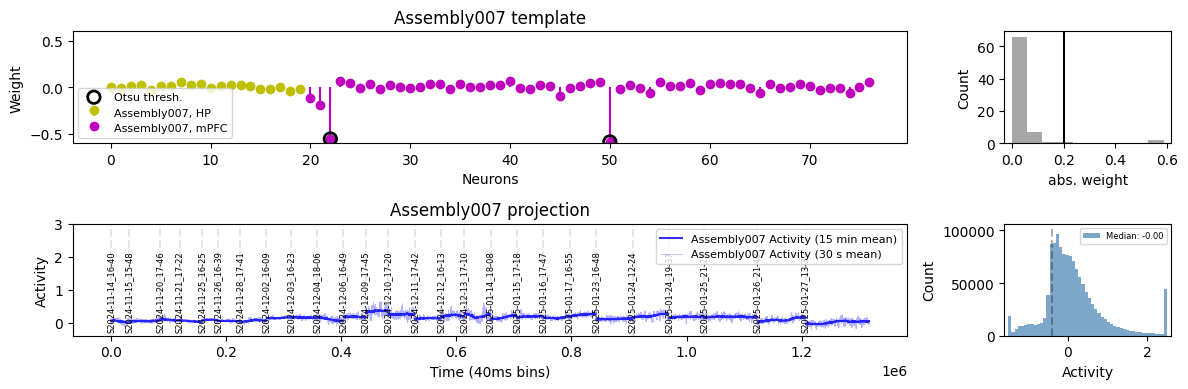

Next session index: 0, session id: 2024-11-14_16-40
Next session index: 32200, session id: 2024-11-15_15-48
Next session index: 85792, session id: 2024-11-20_17-46
Next session index: 119626, session id: 2024-11-21_17-22
Next session index: 158431, session id: 2024-11-25_16-25
Next session index: 185890, session id: 2024-11-26_16-39
Next session index: 224103, session id: 2024-11-28_17-41
Next session index: 270222, session id: 2024-12-02_16-09
Next session index: 313055, session id: 2024-12-03_16-23
Next session index: 358155, session id: 2024-12-04_18-06
Next session index: 403950, session id: 2024-12-06_16-49
Next session index: 442421, session id: 2024-12-09_17-45
Next session index: 481647, session id: 2024-12-10_17-20
Next session index: 528054, session id: 2024-12-11_17-42
Next session index: 573154, session id: 2024-12-12_16-13
Next session index: 613488, session id: 2024-12-13_17-10
Next session index: 659650, session id: 2025-01-14_18-08
Next session index: 705001, session id

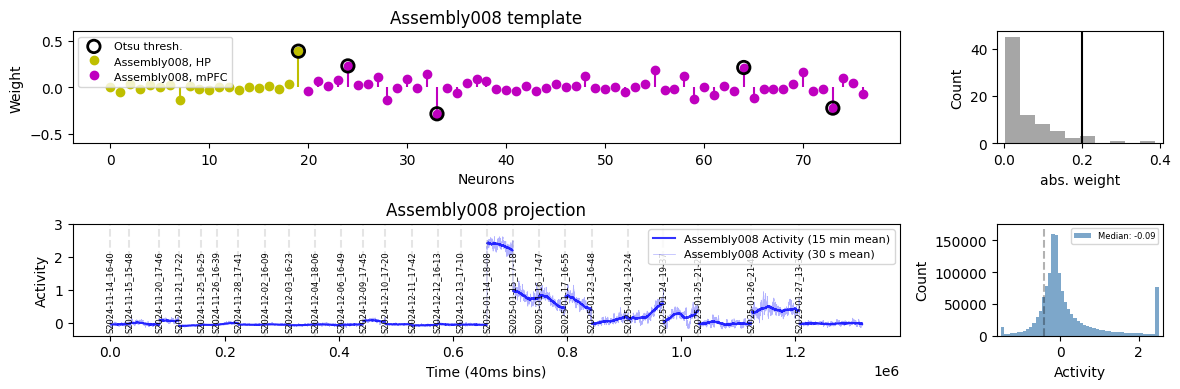

Next session index: 0, session id: 2024-11-14_16-40
Next session index: 32200, session id: 2024-11-15_15-48
Next session index: 85792, session id: 2024-11-20_17-46
Next session index: 119626, session id: 2024-11-21_17-22
Next session index: 158431, session id: 2024-11-25_16-25
Next session index: 185890, session id: 2024-11-26_16-39
Next session index: 224103, session id: 2024-11-28_17-41
Next session index: 270222, session id: 2024-12-02_16-09
Next session index: 313055, session id: 2024-12-03_16-23
Next session index: 358155, session id: 2024-12-04_18-06
Next session index: 403950, session id: 2024-12-06_16-49
Next session index: 442421, session id: 2024-12-09_17-45
Next session index: 481647, session id: 2024-12-10_17-20
Next session index: 528054, session id: 2024-12-11_17-42
Next session index: 573154, session id: 2024-12-12_16-13
Next session index: 613488, session id: 2024-12-13_17-10
Next session index: 659650, session id: 2025-01-14_18-08
Next session index: 705001, session id

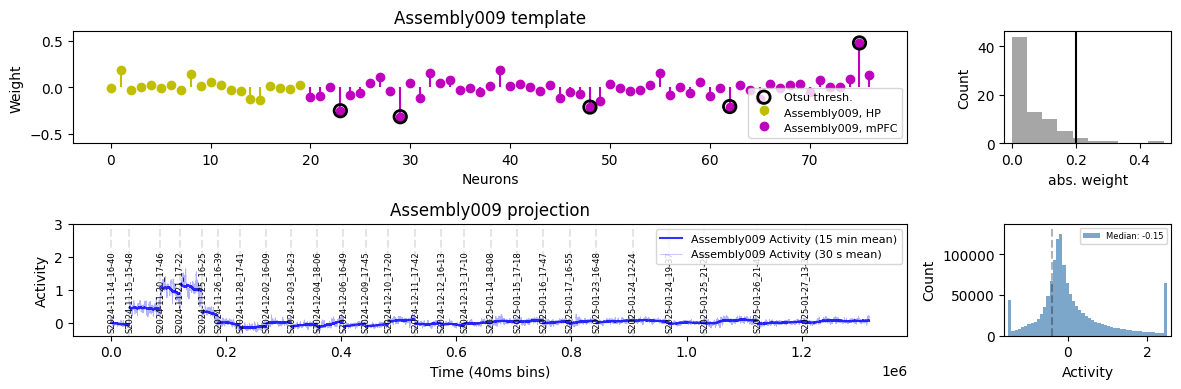

Next session index: 0, session id: 2024-11-14_16-40
Next session index: 32200, session id: 2024-11-15_15-48
Next session index: 85792, session id: 2024-11-20_17-46
Next session index: 119626, session id: 2024-11-21_17-22
Next session index: 158431, session id: 2024-11-25_16-25
Next session index: 185890, session id: 2024-11-26_16-39
Next session index: 224103, session id: 2024-11-28_17-41
Next session index: 270222, session id: 2024-12-02_16-09
Next session index: 313055, session id: 2024-12-03_16-23
Next session index: 358155, session id: 2024-12-04_18-06
Next session index: 403950, session id: 2024-12-06_16-49
Next session index: 442421, session id: 2024-12-09_17-45
Next session index: 481647, session id: 2024-12-10_17-20
Next session index: 528054, session id: 2024-12-11_17-42
Next session index: 573154, session id: 2024-12-12_16-13
Next session index: 613488, session id: 2024-12-13_17-10
Next session index: 659650, session id: 2025-01-14_18-08
Next session index: 705001, session id

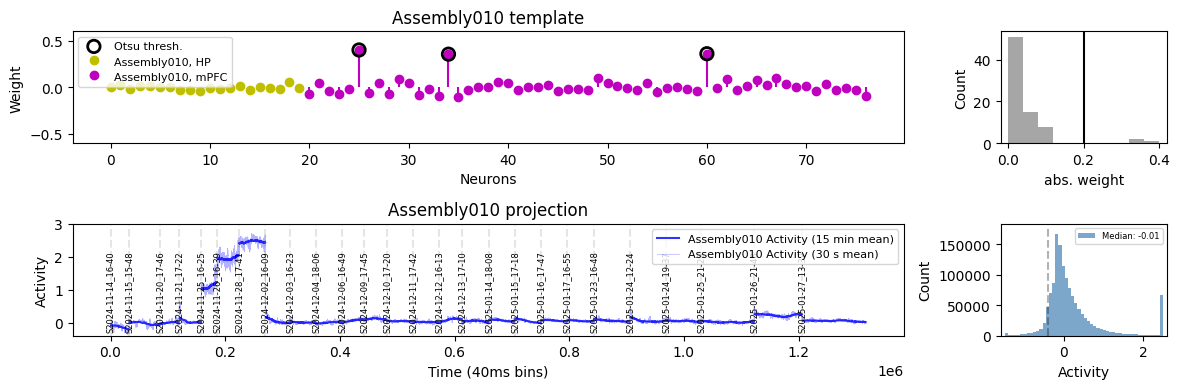

Next session index: 0, session id: 2024-11-14_16-40
Next session index: 32200, session id: 2024-11-15_15-48
Next session index: 85792, session id: 2024-11-20_17-46
Next session index: 119626, session id: 2024-11-21_17-22
Next session index: 158431, session id: 2024-11-25_16-25
Next session index: 185890, session id: 2024-11-26_16-39
Next session index: 224103, session id: 2024-11-28_17-41
Next session index: 270222, session id: 2024-12-02_16-09
Next session index: 313055, session id: 2024-12-03_16-23
Next session index: 358155, session id: 2024-12-04_18-06
Next session index: 403950, session id: 2024-12-06_16-49
Next session index: 442421, session id: 2024-12-09_17-45
Next session index: 481647, session id: 2024-12-10_17-20
Next session index: 528054, session id: 2024-12-11_17-42
Next session index: 573154, session id: 2024-12-12_16-13
Next session index: 613488, session id: 2024-12-13_17-10
Next session index: 659650, session id: 2025-01-14_18-08
Next session index: 705001, session id

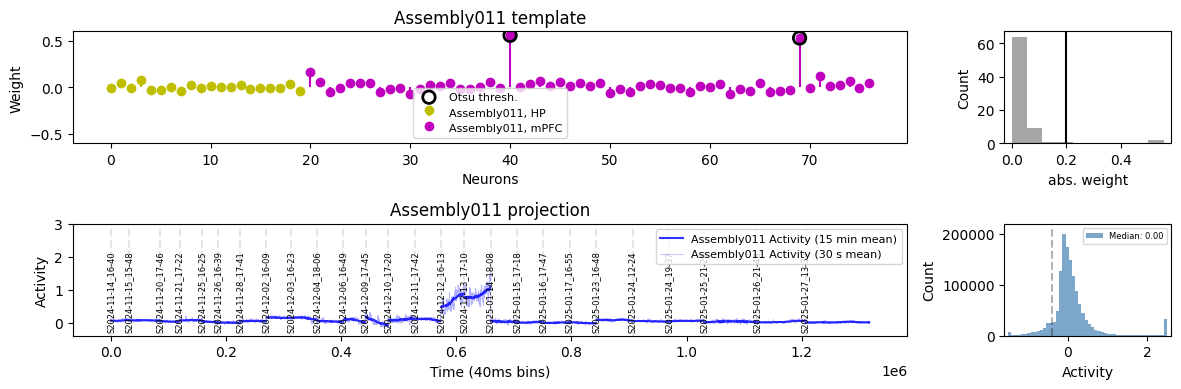

Next session index: 0, session id: 2024-11-14_16-40
Next session index: 32200, session id: 2024-11-15_15-48
Next session index: 85792, session id: 2024-11-20_17-46
Next session index: 119626, session id: 2024-11-21_17-22
Next session index: 158431, session id: 2024-11-25_16-25
Next session index: 185890, session id: 2024-11-26_16-39
Next session index: 224103, session id: 2024-11-28_17-41
Next session index: 270222, session id: 2024-12-02_16-09
Next session index: 313055, session id: 2024-12-03_16-23
Next session index: 358155, session id: 2024-12-04_18-06
Next session index: 403950, session id: 2024-12-06_16-49
Next session index: 442421, session id: 2024-12-09_17-45
Next session index: 481647, session id: 2024-12-10_17-20
Next session index: 528054, session id: 2024-12-11_17-42
Next session index: 573154, session id: 2024-12-12_16-13
Next session index: 613488, session id: 2024-12-13_17-10
Next session index: 659650, session id: 2025-01-14_18-08
Next session index: 705001, session id

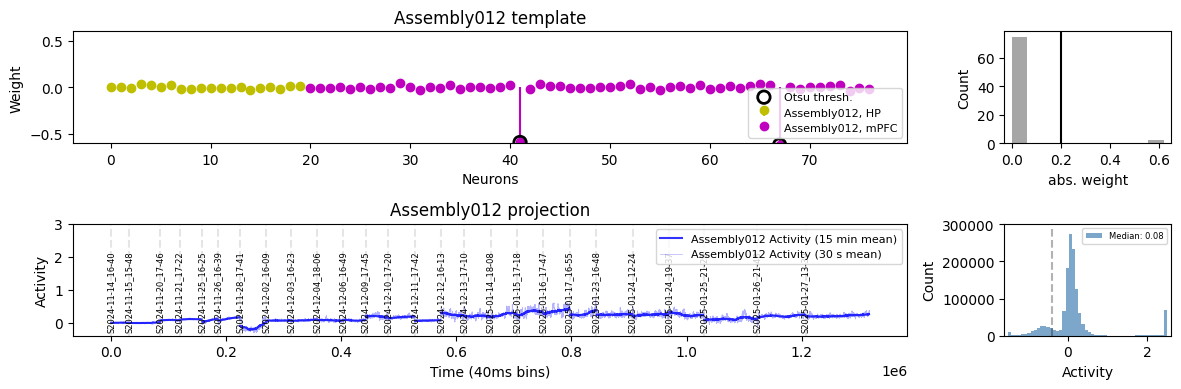

Next session index: 0, session id: 2024-11-14_16-40
Next session index: 32200, session id: 2024-11-15_15-48
Next session index: 85792, session id: 2024-11-20_17-46
Next session index: 119626, session id: 2024-11-21_17-22
Next session index: 158431, session id: 2024-11-25_16-25
Next session index: 185890, session id: 2024-11-26_16-39
Next session index: 224103, session id: 2024-11-28_17-41
Next session index: 270222, session id: 2024-12-02_16-09
Next session index: 313055, session id: 2024-12-03_16-23
Next session index: 358155, session id: 2024-12-04_18-06
Next session index: 403950, session id: 2024-12-06_16-49
Next session index: 442421, session id: 2024-12-09_17-45
Next session index: 481647, session id: 2024-12-10_17-20
Next session index: 528054, session id: 2024-12-11_17-42
Next session index: 573154, session id: 2024-12-12_16-13
Next session index: 613488, session id: 2024-12-13_17-10
Next session index: 659650, session id: 2025-01-14_18-08
Next session index: 705001, session id

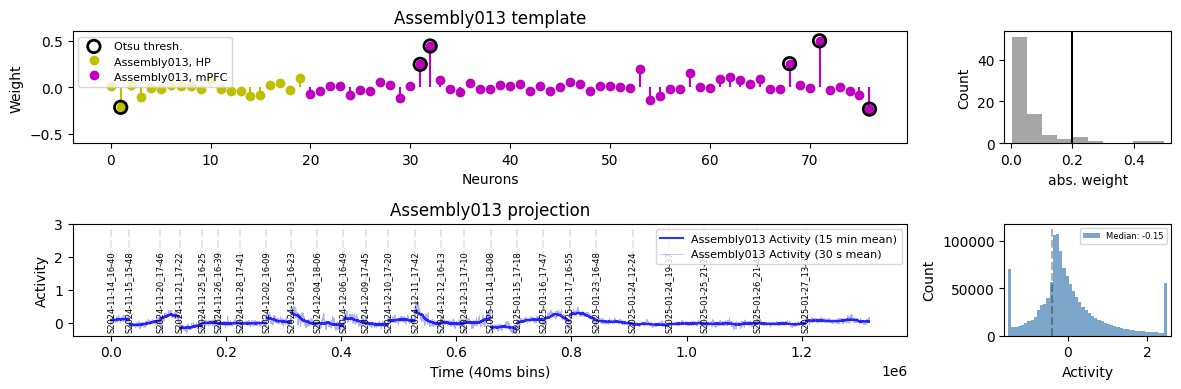

Next session index: 0, session id: 2024-11-14_16-40
Next session index: 32200, session id: 2024-11-15_15-48
Next session index: 85792, session id: 2024-11-20_17-46
Next session index: 119626, session id: 2024-11-21_17-22
Next session index: 158431, session id: 2024-11-25_16-25
Next session index: 185890, session id: 2024-11-26_16-39
Next session index: 224103, session id: 2024-11-28_17-41
Next session index: 270222, session id: 2024-12-02_16-09
Next session index: 313055, session id: 2024-12-03_16-23
Next session index: 358155, session id: 2024-12-04_18-06
Next session index: 403950, session id: 2024-12-06_16-49
Next session index: 442421, session id: 2024-12-09_17-45
Next session index: 481647, session id: 2024-12-10_17-20
Next session index: 528054, session id: 2024-12-11_17-42
Next session index: 573154, session id: 2024-12-12_16-13
Next session index: 613488, session id: 2024-12-13_17-10
Next session index: 659650, session id: 2025-01-14_18-08
Next session index: 705001, session id

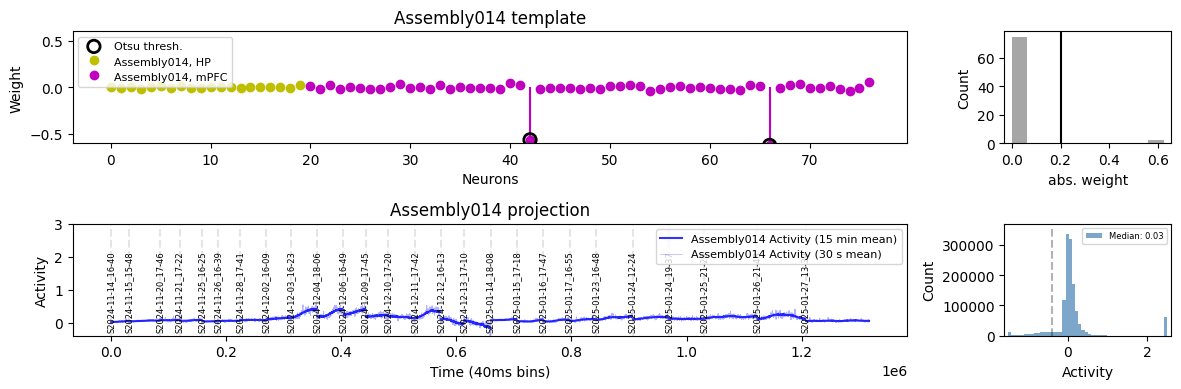

Next session index: 0, session id: 2024-11-14_16-40
Next session index: 32200, session id: 2024-11-15_15-48
Next session index: 85792, session id: 2024-11-20_17-46
Next session index: 119626, session id: 2024-11-21_17-22
Next session index: 158431, session id: 2024-11-25_16-25
Next session index: 185890, session id: 2024-11-26_16-39
Next session index: 224103, session id: 2024-11-28_17-41
Next session index: 270222, session id: 2024-12-02_16-09
Next session index: 313055, session id: 2024-12-03_16-23
Next session index: 358155, session id: 2024-12-04_18-06
Next session index: 403950, session id: 2024-12-06_16-49
Next session index: 442421, session id: 2024-12-09_17-45
Next session index: 481647, session id: 2024-12-10_17-20
Next session index: 528054, session id: 2024-12-11_17-42
Next session index: 573154, session id: 2024-12-12_16-13
Next session index: 613488, session id: 2024-12-13_17-10
Next session index: 659650, session id: 2025-01-14_18-08
Next session index: 705001, session id

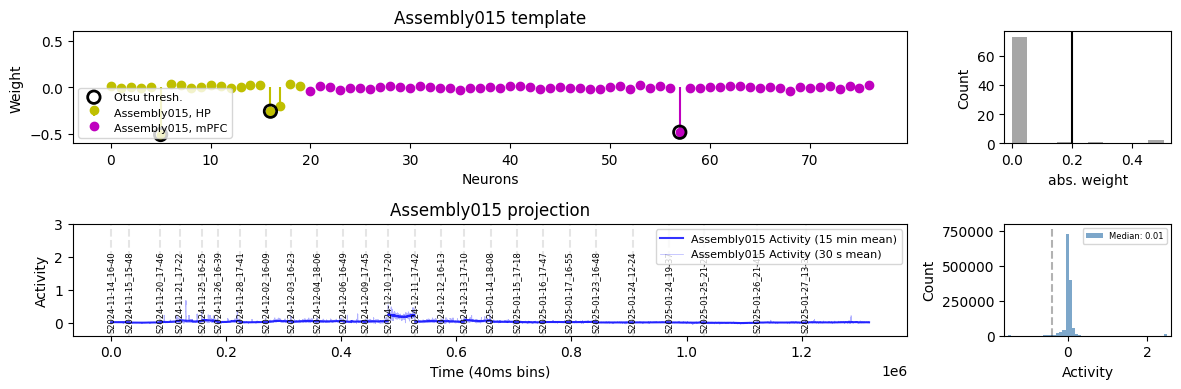

Next session index: 0, session id: 2024-11-14_16-40
Next session index: 32200, session id: 2024-11-15_15-48
Next session index: 85792, session id: 2024-11-20_17-46
Next session index: 119626, session id: 2024-11-21_17-22
Next session index: 158431, session id: 2024-11-25_16-25
Next session index: 185890, session id: 2024-11-26_16-39
Next session index: 224103, session id: 2024-11-28_17-41
Next session index: 270222, session id: 2024-12-02_16-09
Next session index: 313055, session id: 2024-12-03_16-23
Next session index: 358155, session id: 2024-12-04_18-06
Next session index: 403950, session id: 2024-12-06_16-49
Next session index: 442421, session id: 2024-12-09_17-45
Next session index: 481647, session id: 2024-12-10_17-20
Next session index: 528054, session id: 2024-12-11_17-42
Next session index: 573154, session id: 2024-12-12_16-13
Next session index: 613488, session id: 2024-12-13_17-10
Next session index: 659650, session id: 2025-01-14_18-08
Next session index: 705001, session id

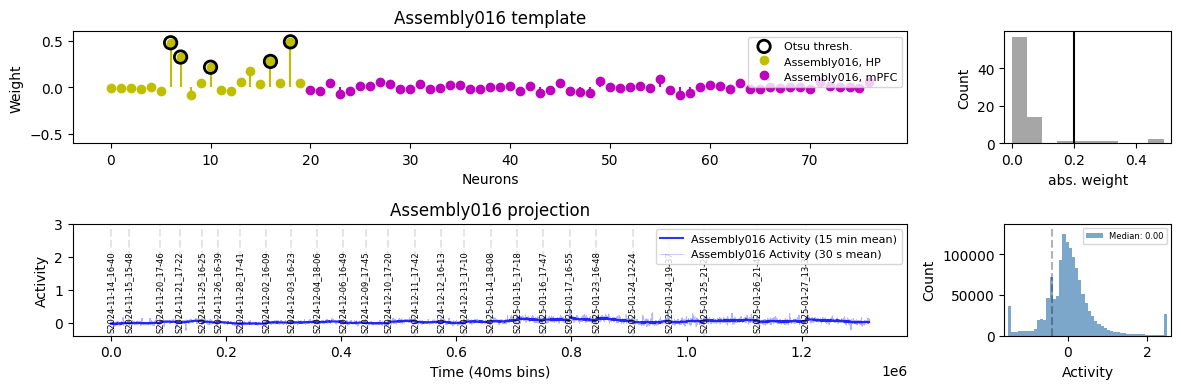

Next session index: 0, session id: 2024-11-14_16-40
Next session index: 32200, session id: 2024-11-15_15-48
Next session index: 85792, session id: 2024-11-20_17-46
Next session index: 119626, session id: 2024-11-21_17-22
Next session index: 158431, session id: 2024-11-25_16-25
Next session index: 185890, session id: 2024-11-26_16-39
Next session index: 224103, session id: 2024-11-28_17-41
Next session index: 270222, session id: 2024-12-02_16-09
Next session index: 313055, session id: 2024-12-03_16-23
Next session index: 358155, session id: 2024-12-04_18-06
Next session index: 403950, session id: 2024-12-06_16-49
Next session index: 442421, session id: 2024-12-09_17-45
Next session index: 481647, session id: 2024-12-10_17-20
Next session index: 528054, session id: 2024-12-11_17-42
Next session index: 573154, session id: 2024-12-12_16-13
Next session index: 613488, session id: 2024-12-13_17-10
Next session index: 659650, session id: 2025-01-14_18-08
Next session index: 705001, session id

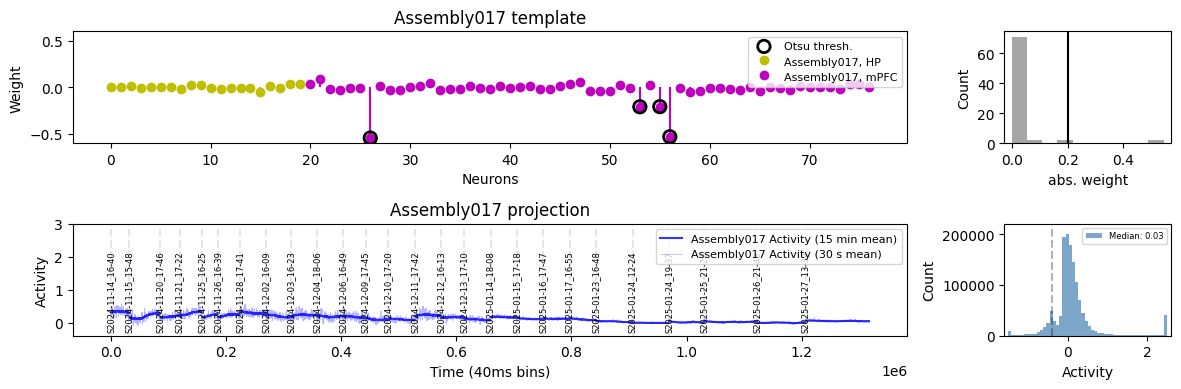

Next session index: 0, session id: 2024-11-14_16-40
Next session index: 32200, session id: 2024-11-15_15-48
Next session index: 85792, session id: 2024-11-20_17-46
Next session index: 119626, session id: 2024-11-21_17-22
Next session index: 158431, session id: 2024-11-25_16-25
Next session index: 185890, session id: 2024-11-26_16-39
Next session index: 224103, session id: 2024-11-28_17-41
Next session index: 270222, session id: 2024-12-02_16-09
Next session index: 313055, session id: 2024-12-03_16-23
Next session index: 358155, session id: 2024-12-04_18-06
Next session index: 403950, session id: 2024-12-06_16-49
Next session index: 442421, session id: 2024-12-09_17-45
Next session index: 481647, session id: 2024-12-10_17-20
Next session index: 528054, session id: 2024-12-11_17-42
Next session index: 573154, session id: 2024-12-12_16-13
Next session index: 613488, session id: 2024-12-13_17-10
Next session index: 659650, session id: 2025-01-14_18-08
Next session index: 705001, session id

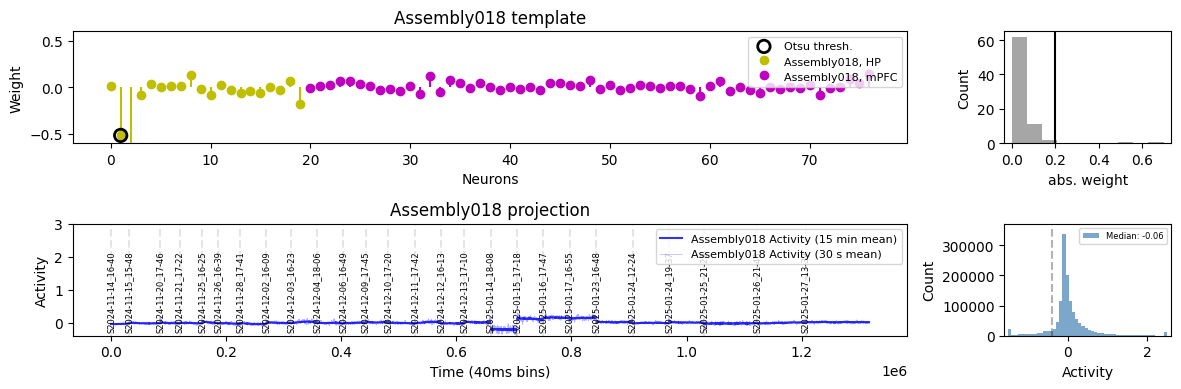

Next session index: 0, session id: 2024-11-14_16-40
Next session index: 32200, session id: 2024-11-15_15-48
Next session index: 85792, session id: 2024-11-20_17-46
Next session index: 119626, session id: 2024-11-21_17-22
Next session index: 158431, session id: 2024-11-25_16-25
Next session index: 185890, session id: 2024-11-26_16-39
Next session index: 224103, session id: 2024-11-28_17-41
Next session index: 270222, session id: 2024-12-02_16-09
Next session index: 313055, session id: 2024-12-03_16-23
Next session index: 358155, session id: 2024-12-04_18-06
Next session index: 403950, session id: 2024-12-06_16-49
Next session index: 442421, session id: 2024-12-09_17-45
Next session index: 481647, session id: 2024-12-10_17-20
Next session index: 528054, session id: 2024-12-11_17-42
Next session index: 573154, session id: 2024-12-12_16-13
Next session index: 613488, session id: 2024-12-13_17-10
Next session index: 659650, session id: 2025-01-14_18-08
Next session index: 705001, session id

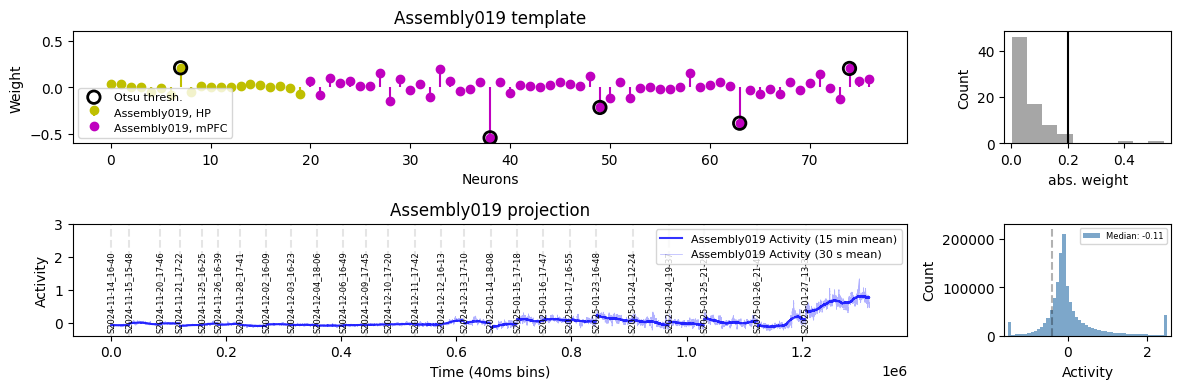

Next session index: 0, session id: 2024-11-14_16-40
Next session index: 32200, session id: 2024-11-15_15-48
Next session index: 85792, session id: 2024-11-20_17-46
Next session index: 119626, session id: 2024-11-21_17-22
Next session index: 158431, session id: 2024-11-25_16-25
Next session index: 185890, session id: 2024-11-26_16-39
Next session index: 224103, session id: 2024-11-28_17-41
Next session index: 270222, session id: 2024-12-02_16-09
Next session index: 313055, session id: 2024-12-03_16-23
Next session index: 358155, session id: 2024-12-04_18-06
Next session index: 403950, session id: 2024-12-06_16-49
Next session index: 442421, session id: 2024-12-09_17-45
Next session index: 481647, session id: 2024-12-10_17-20
Next session index: 528054, session id: 2024-12-11_17-42
Next session index: 573154, session id: 2024-12-12_16-13
Next session index: 613488, session id: 2024-12-13_17-10
Next session index: 659650, session id: 2025-01-14_18-08
Next session index: 705001, session id

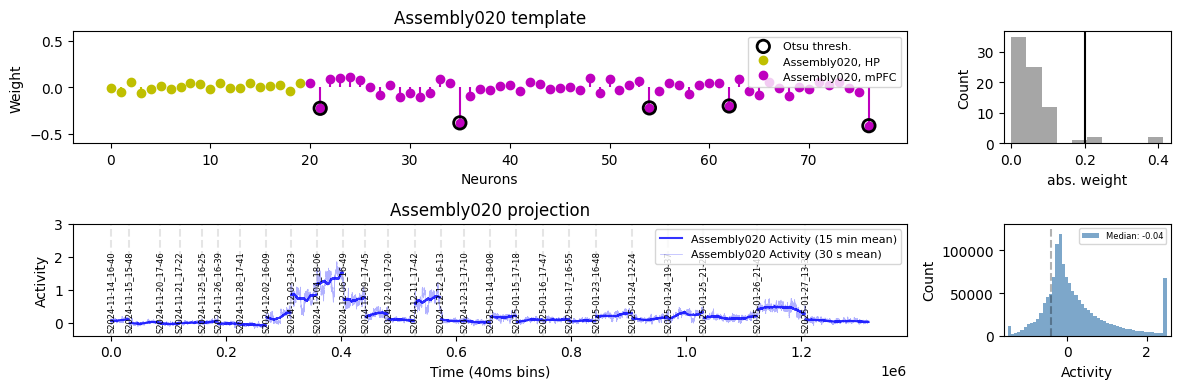

Next session index: 0, session id: 2024-11-14_16-40
Next session index: 32200, session id: 2024-11-15_15-48
Next session index: 85792, session id: 2024-11-20_17-46
Next session index: 119626, session id: 2024-11-21_17-22
Next session index: 158431, session id: 2024-11-25_16-25
Next session index: 185890, session id: 2024-11-26_16-39
Next session index: 224103, session id: 2024-11-28_17-41
Next session index: 270222, session id: 2024-12-02_16-09
Next session index: 313055, session id: 2024-12-03_16-23
Next session index: 358155, session id: 2024-12-04_18-06
Next session index: 403950, session id: 2024-12-06_16-49
Next session index: 442421, session id: 2024-12-09_17-45
Next session index: 481647, session id: 2024-12-10_17-20
Next session index: 528054, session id: 2024-12-11_17-42
Next session index: 573154, session id: 2024-12-12_16-13
Next session index: 613488, session id: 2024-12-13_17-10
Next session index: 659650, session id: 2025-01-14_18-08
Next session index: 705001, session id

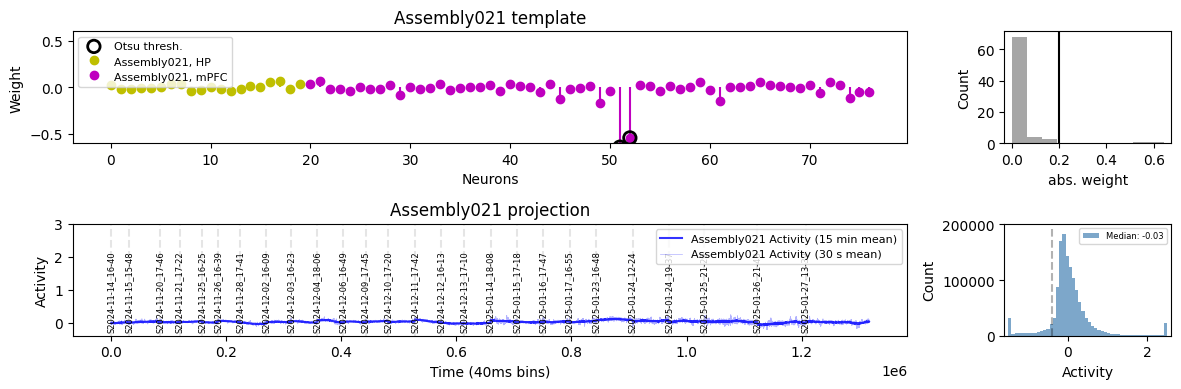

Next session index: 0, session id: 2024-11-14_16-40
Next session index: 32200, session id: 2024-11-15_15-48
Next session index: 85792, session id: 2024-11-20_17-46
Next session index: 119626, session id: 2024-11-21_17-22
Next session index: 158431, session id: 2024-11-25_16-25
Next session index: 185890, session id: 2024-11-26_16-39
Next session index: 224103, session id: 2024-11-28_17-41
Next session index: 270222, session id: 2024-12-02_16-09
Next session index: 313055, session id: 2024-12-03_16-23
Next session index: 358155, session id: 2024-12-04_18-06
Next session index: 403950, session id: 2024-12-06_16-49
Next session index: 442421, session id: 2024-12-09_17-45
Next session index: 481647, session id: 2024-12-10_17-20
Next session index: 528054, session id: 2024-12-11_17-42
Next session index: 573154, session id: 2024-12-12_16-13
Next session index: 613488, session id: 2024-12-13_17-10
Next session index: 659650, session id: 2025-01-14_18-08
Next session index: 705001, session id

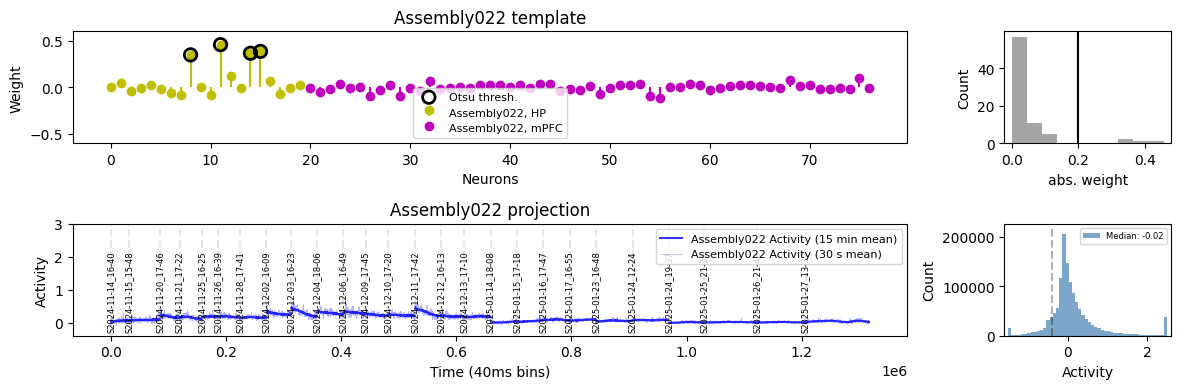

Next session index: 0, session id: 2024-11-14_16-40
Next session index: 32200, session id: 2024-11-15_15-48
Next session index: 85792, session id: 2024-11-20_17-46
Next session index: 119626, session id: 2024-11-21_17-22
Next session index: 158431, session id: 2024-11-25_16-25
Next session index: 185890, session id: 2024-11-26_16-39
Next session index: 224103, session id: 2024-11-28_17-41
Next session index: 270222, session id: 2024-12-02_16-09
Next session index: 313055, session id: 2024-12-03_16-23
Next session index: 358155, session id: 2024-12-04_18-06
Next session index: 403950, session id: 2024-12-06_16-49
Next session index: 442421, session id: 2024-12-09_17-45
Next session index: 481647, session id: 2024-12-10_17-20
Next session index: 528054, session id: 2024-12-11_17-42
Next session index: 573154, session id: 2024-12-12_16-13
Next session index: 613488, session id: 2024-12-13_17-10
Next session index: 659650, session id: 2025-01-14_18-08
Next session index: 705001, session id

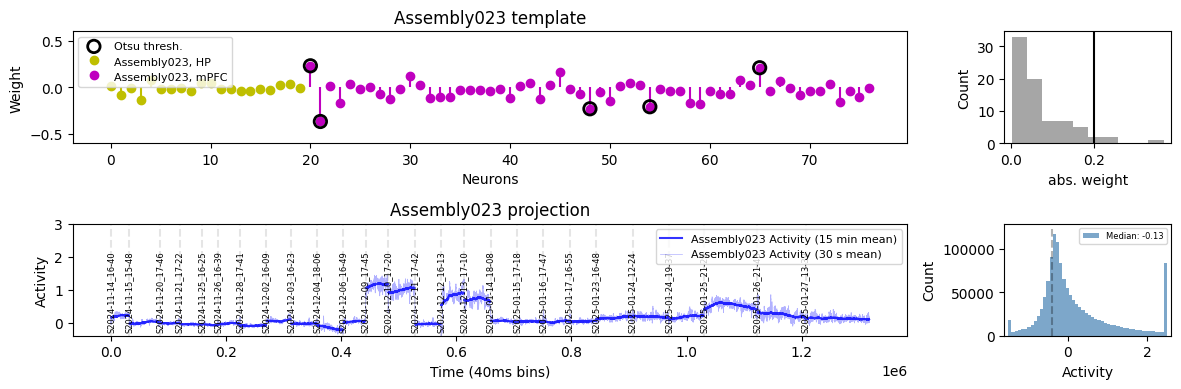

In [25]:
for i in ensambles.columns:
    fig, ax = plt.subplots(ncols=2, nrows=2, figsize=(12, 4), width_ratios=(5,1))
    # fig, ax = plt.subplots(ncols=2, nrows=2, figsize=(29, 6), width_ratios=(15,1))
    ax = ax.flatten()
    ax[0].set_title(f'{i} template')
    ax[0].set_xlabel('Neurons')
    ax[0].set_ylabel('Weight')
    
    
    markerline1 = ax[0].stem(np.arange(20), ensambles[i].iloc[:20], label=f'{i}, HP', linefmt='y-', markerfmt='yo', basefmt=" ")
    markerline2 = ax[0].stem(np.arange(20, ensambles.shape[0]), ensambles[i].iloc[20:], label=f'{i}, mPFC', linefmt='m-', markerfmt='mo', basefmt=" ")
    
    # Draw circles only for high weight
    thr = .2
    x = np.arange(ensambles.shape[0])[np.abs(ensambles[i]) > thr]
    ax[0].scatter(x, ensambles[i][np.abs(ensambles[i]) > thr], s=80, facecolors='none', 
                  edgecolors='k', linewidths=2, zorder=3, label='Otsu thresh.')

    lims = (-.6, .6)
    ax[0].set_ylim(lims)
    ax[0].legend(fontsize=8)

    ax[1].hist(np.abs(ensambles[i]), bins=10, label=f'{i} Activity', color='gray', alpha=0.7)
    ax[1].axvline(x=thr, color='k')
    ax[1].set_xlabel("abs. weight")
    ax[1].set_ylabel("Count")

    ax[2].set_title(f'{i} projection')
    ax[2].set_xlabel('Time (40ms bins)')
    ax[2].set_ylabel('Activity')
    # ax[2].set_ylim(-.8,.8)
    
    # real = np.clip(ensamble_proj[i], -5, 5)
    # ax[2].scatter(np.arange(len(real)), real.values, label=f'{i} Activity (25 ms)', color='red', alpha=0.04, s=1)
    
    activity_lims = (-.4, 3, )
    
    smoothed = np.clip(ensamble_proj[i], -3, 3).groupby(level='session_id').rolling(window=25*60*15, center=True, min_periods=25*60*8 ).mean().values
    ax[2].plot(smoothed, label=f'{i} Activity (15 min mean)', color='blue', alpha=.8)

    smoothed = np.clip(ensamble_proj[i], -3, 3).groupby(level='session_id').rolling(window=25*30, center=True, min_periods=1 ).mean().values
    ax[2].plot(smoothed, label=f'{i} Activity (30 s mean)', color='blue', alpha=.3, linewidth=0.5)

    sample_cnt = 0
    for s_id in ensamble_proj.index.unique(level='session_id'):
        print(f"Next session index: {sample_cnt}, session id: {s_id}")
        # kwargs = {'label': 'next session'} if sample_cnt == 0 else {}
        ax[2].axvline(x=sample_cnt, color='gray', linestyle='--', alpha=0.2,)
        ax[2].annotate(f'S{s_id:02}', xy=(sample_cnt, activity_lims[0]), xytext=(sample_cnt, activity_lims[0]+.1),
                       fontsize=6, color='black', rotation=90, va='bottom', ha='center')
        sample_cnt += len(ensamble_proj.loc[s_id])
    ax[2].set_ylim(activity_lims)
    ax[2].legend(fontsize=8)

    # plot the ensemble projection histogram
    med = np.nanmedian(ensamble_proj[i])
    ax[3].hist(np.clip(ensamble_proj[i], -1.5, 2.5), bins=50, color='steelblue', alpha=0.7, label=f"Median: {med:.2f}")
    ax[3].vlines(activity_lims, ymin=0, ymax=ax[3].get_ylim()[1], color='k', linestyles='--', alpha=.3)
    ax[3].set_xlabel('Activity')
    ax[3].set_ylabel('Count')
    ax[3].legend(fontsize=6)
    ax[3].set_xlim(-1.6, 2.6)
    plt.tight_layout()
    plt.show()


In [26]:
# project single units on PCs (every column), fr has shape every column is one unity, every row one timepoint
pca_loadings_concat = pd.DataFrame((pca_components.values @ fr_z.T.values).T, 
                                    columns=pca_loadings_sessions.columns)